# Работу выполнил Ислам Закиров БИВТ-22-16

## Загрузка данных

In [3]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import numpy as np
from sklearn.cluster import KMeans
from sklearn.preprocessing import StandardScaler

data = pd.read_csv('Physical_Activity_Monitoring_unlabeled.csv')

Датасет содержит по 54 столбца на строку, столбцы содержат следующие данные:

1 временная метка (с)

2 частота сердечных сокращений (уд/мин)

3-19 данные с датчиков на руке

20-36 данные с датчиков на груди

37-53 данные с датчиков на лодыжке

Сенсорные данные IMU содержат следующие столбцы:

1 температура (°C)
2-4 Данные 3D-ускорения (мс-2), масштаб: ±16g, разрешение: 13 бит
5-7 Данные 3D-ускорения (мс-2), масштаб: ±6g, разрешение: 13 бит*
8-10 данных 3D-гироскопа (рад/с)
11-13 Данные 3D-магнитометра (мкТл)

## Обзор данных

In [26]:
print(data.head())

   timestamp  handTemperature  handAcc16_1  handAcc16_2  handAcc16_3  \
0     252.75          34.8750     0.902847      7.45872     6.032490   
1    3652.45          29.7500    -4.069330      3.76168     8.279720   
2     504.76          34.3750    -2.007540     -9.60180     0.773674   
3    2801.61          31.9375   -13.262200      5.85443     0.899334   
4     441.01          33.5000    -0.013940      8.66540     4.398210   

   handAcc6_1  handAcc6_2  handAcc6_3  handGyro1  handGyro2  ...  ankleGyro2  \
0    1.006100     7.44575    6.303650  -0.021952   0.004114  ...   -0.025606   
1   -5.972500     3.22273    6.908970   0.116054  -0.375968  ...   -0.670163   
2   -1.803500    -9.58937    1.073680   0.020131   0.042189  ...   -0.009741   
3  -13.611500     5.91511    0.840377   1.715630  -0.050492  ...   -0.163470   
4    0.144153     8.56816    4.822200  -0.006938  -0.007383  ...   -0.028172   

   ankleGyro3  ankleMagne1  ankleMagne2  ankleMagne3  ankleOrientation1  \
0    0.0302

In [27]:
print(data.info())

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 534601 entries, 0 to 534600
Data columns (total 53 columns):
 #   Column             Non-Null Count   Dtype  
---  ------             --------------   -----  
 0   timestamp          534601 non-null  float64
 1   handTemperature    530560 non-null  float64
 2   handAcc16_1        530560 non-null  float64
 3   handAcc16_2        530560 non-null  float64
 4   handAcc16_3        530560 non-null  float64
 5   handAcc6_1         530560 non-null  float64
 6   handAcc6_2         530560 non-null  float64
 7   handAcc6_3         530560 non-null  float64
 8   handGyro1          530560 non-null  float64
 9   handGyro2          530560 non-null  float64
 10  handGyro3          530560 non-null  float64
 11  handMagne1         530560 non-null  float64
 12  handMagne2         530560 non-null  float64
 13  handMagne3         530560 non-null  float64
 14  handOrientation1   530560 non-null  float64
 15  handOrientation2   530560 non-null  float64
 16  ha

In [31]:
print(data.describe())

       handTemperature    handAcc16_1    handAcc16_2    handAcc16_3  \
count    530560.000000  530560.000000  530560.000000  530560.000000   
mean         32.451221      -4.435286       3.241949       4.079375   
std           1.754847       7.062004       7.224031       3.831257   
min          27.500000    -114.755000     -82.550900     -73.949700   
25%          31.312500      -9.076360       0.682775       1.588777   
50%          32.875000      -5.465610       3.089205       4.157125   
75%          33.812500       0.383679       5.559742       6.864212   
max          35.250000      60.912600     155.532000      78.480100   

          handAcc6_1     handAcc6_2     handAcc6_3      handGyro1  \
count  530560.000000  530560.000000  530560.000000  530560.000000   
mean       -4.375896       3.218250       4.262513      -0.008852   
std         7.068961       6.864782       3.822053       1.160112   
min       -61.214700     -61.824200     -61.577100     -19.690500   
25%        -8.9

## Предварительная обработка данных

In [134]:
sensor_columns = data.drop(columns=['timestamp', 'subject_id'])

In [135]:
for column in sensor_columns:
    print(f'{column} - min: {data[column].min()}, max: {data[column].max()}, mean: {data[column].mean()}, std: {data[column].std()}')

handTemperature - min: 27.5, max: 35.25, mean: 32.451220879825094, std: 1.7548469654986298
handAcc16_1 - min: -114.755, max: 60.9126, mean: -4.435285675995672, std: 7.06200369282318
handAcc16_2 - min: -82.5509, max: 155.532, mean: 3.2419489963718675, std: 7.22403119459206
handAcc16_3 - min: -73.9497, max: 78.4801, mean: 4.07937525223517, std: 3.8312574070266168
handAcc6_1 - min: -61.2147, max: 34.1594, mean: -4.375895710202184, std: 7.068961163781854
handAcc6_2 - min: -61.8242, max: 62.2598, mean: 3.218249888658998, std: 6.864782005879805
handAcc6_3 - min: -61.5771, max: 60.8437, mean: 4.262513013318957, std: 3.8220529716795753
handGyro1 - min: -19.6905, max: 22.96, mean: -0.008852222986090239, std: 1.1601121132267571
handGyro2 - min: -7.60901, max: 11.8626, mean: 0.028801428457911817, std: 0.9268319380557432
handGyro3 - min: -14.2647, max: 14.3267, mean: 1.4540067404206207e-05, std: 1.6164369264733789
handMagne1 - min: -74.6, max: 128.824, mean: 20.396467486119136, std: 23.94259279342

In [58]:
len(sensor_columns.columns)

51

In [136]:
hand_columns = sensor_columns[sensor_columns.columns[:17]]
chest_columns = sensor_columns[sensor_columns.columns[17:34]] 
ankle_columns = sensor_columns[sensor_columns.columns[34:]] 

In [80]:
hand_columns

,handTemperature,handAcc16_1,handAcc16_2,handAcc16_3,handAcc6_1,handAcc6_2,handAcc6_3,handGyro1,handGyro2,handGyro3,handMagne1,handMagne2,handMagne3,handOrientation1,handOrientation2,handOrientation3,handOrientation4
0,34.8750,0.902847,7.45872,6.032490,1.006100,7.44575,6.303650,-0.021952,0.004114,-0.000752,-9.99538,7.22910,-32.13990,0.561813,-0.218644,0.359836,0.712095
1,29.7500,-4.069330,3.76168,8.279720,-5.972500,3.22273,6.908970,0.116054,-0.375968,-0.012890,40.45580,-1.19692,-37.55520,0.884964,-0.281047,-0.145657,0.341518
2,34.3750,-2.007540,-9.60180,0.773674,-1.803500,-9.58937,1.073680,0.020131,0.042189,-0.011507,7.26741,24.43790,-14.30050,0.535655,0.564385,0.371967,-0.506146
3,31.9375,-13.262200,5.85443,0.899334,-13.611500,5.91511,0.840377,1.715630,-0.050492,-1.829000,46.48220,-7.83916,-13.62420,0.648205,0.540984,-0.282560,-0.455332
4,33.5000,-0.013940,8.66540,4.398210,0.144153,8.56816,4.822200,-0.006938,-0.007383,-0.032679,3.97764,-22.42320,-20.17750,0.769041,-0.442364,0.232331,0.398638
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
534596,33.8750,-9.084250,4.70122,2.890170,-9.689610,6.78077,3.975430,-0.157406,0.774189,4.369120,20.63540,-28.77620,-25.42200,0.528022,-0.503806,0.001345,0.683645
534597,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
534598,34.6875,-6.367550,2.32131,2.207640,-6.362460,2.33049,2.607610,0.206349,-0.359415,1.963340,33.81300,-37.06100,-42.32740,0.020073,0.624333,-0.226756,-0.747254
534599,28.0625,5.461940,10.43640,-9.073300,8.348860,5.76518,-6.143210,3.543910,2.757300,0.087904,38.75990,-30.96050,10.11840,0.899430,-0.038416,0.208645,-0.382123


In [87]:
chest_columns

,chestTemperature,chestAcc16_1,chestAcc16_2,chestAcc16_3,chestAcc6_1,chestAcc6_2,chestAcc6_3,chestGyro1,chestGyro2,chestGyro3,chestMagne1,chestMagne2,chestMagne3,chestOrientation1,chestOrientation2,chestOrientation3,chestOrientation4
0,36.6250,-0.106754,1.66721,9.327970,-0.292054,1.56048,9.749260,-0.019807,-0.034096,0.003963,39.54660,5.58050,-27.96600,0.987675,-0.081231,-0.009229,0.133472
1,34.6875,0.069756,2.61466,-11.891000,-0.139514,2.40386,-10.968600,0.299329,0.272314,0.249314,17.42950,2.61508,39.32980,0.155581,-0.908072,-0.388069,-0.024528
2,37.6250,0.326521,9.81131,0.016322,0.261230,9.78271,0.460448,0.009436,-0.015007,-0.037835,5.63520,-25.82200,-3.77094,0.721119,-0.680477,0.090302,0.093721
3,36.5000,2.127460,8.91873,-8.582920,2.372620,9.73020,-8.650230,0.078109,-0.099471,0.488145,-1.19466,-38.68970,5.28249,0.367155,-0.663333,0.553109,0.345336
4,35.8125,0.648395,9.73894,0.603203,0.519639,9.79662,0.897193,0.003127,-0.015282,-0.061410,4.60037,-25.65500,-3.63808,0.735751,-0.666812,0.086031,0.081430
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
534596,36.4375,0.349131,12.59240,-0.766727,0.768108,14.34050,-0.103653,-0.856408,1.843010,-0.641021,-3.53125,-32.34330,19.32700,0.467365,-0.645026,-0.507466,-0.328618
534597,38.2500,3.036610,11.28270,-3.811460,3.087070,12.18010,-2.436150,-0.216822,-0.467556,0.598908,-7.27989,-38.10290,-13.37940,0.468146,-0.376941,0.566519,0.563748
534598,38.3125,0.722685,4.53646,-0.269123,0.406731,4.56063,0.142151,0.153337,-0.140053,-0.491834,16.32450,-51.98580,-26.39070,0.653617,-0.698854,0.259103,0.131353
534599,33.1875,0.323335,36.66410,-10.332100,4.408930,35.13650,-4.447880,0.999083,1.055100,-0.961515,-13.92660,-38.02440,22.53010,0.209711,0.217937,0.808571,0.504715


In [92]:
ankle_columns

,ankleTemperature,ankleAcc16_1,ankleAcc16_2,ankleAcc16_3,ankleAcc6_1,ankleAcc6_2,ankleAcc6_3,ankleGyro1,ankleGyro2,ankleGyro3,ankleMagne1,ankleMagne2,ankleMagne3,ankleOrientation1,ankleOrientation2,ankleOrientation3,ankleOrientation4
0,34.1250,-0.458486,-9.074420,-4.47955,-0.318531,-8.899070,-4.13847,0.043954,-0.025606,0.030239,-14.54470,27.3336,-5.766200,0.206416,0.348212,0.763201,-0.503652
1,33.6250,6.035340,2.787170,-2.05542,6.397190,4.930160,-1.31267,-0.319186,-0.670163,1.786200,-32.82570,-15.7719,-1.313950,0.578332,-0.566734,0.405888,-0.423791
2,33.9375,9.238750,2.809250,-2.56296,9.142330,2.918150,-2.12294,0.065654,-0.009741,-0.006579,-18.81710,16.3089,25.292800,0.139776,0.676586,0.393796,0.606316
3,34.5625,13.540000,3.082240,2.57328,18.086300,1.822210,2.91851,2.970010,-0.163470,-3.495570,-26.74180,34.3566,21.327400,0.416303,0.783387,0.306464,0.345075
4,34.6875,9.551770,-0.494227,-2.77079,9.545500,-0.394571,-2.47767,0.013953,-0.028172,-0.003737,-17.77980,-3.9981,10.995000,0.171133,-0.748343,0.252988,-0.588807
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
534596,34.1250,22.677700,0.566425,-3.22160,24.036100,2.540910,-4.12301,-0.693049,0.424520,-0.856836,-25.00990,-23.5557,23.615300,0.318171,-0.701921,0.555778,-0.311745
534597,34.1875,5.223210,2.080800,-17.26370,6.310440,4.766610,-11.33120,1.619630,-1.767710,-3.050980,-35.70240,31.8018,16.421800,0.435887,0.660643,0.371665,0.485200
534598,34.3125,9.487840,-0.725098,-2.34552,9.322240,-0.666238,-1.96102,-0.741392,-0.034144,-0.402013,-49.69220,20.6039,-0.917908,0.561652,0.297957,0.756767,0.151899
534599,33.8125,3.000680,4.100200,-2.44200,1.172660,28.565700,-16.63240,-3.427920,0.352062,-5.577750,-34.15510,-11.0786,39.737500,0.062163,-0.798705,-0.056668,-0.595815


## Проверка на пропуски

In [137]:
data.isna().sum()

timestamp               0
handTemperature      4041
handAcc16_1          4041
handAcc16_2          4041
handAcc16_3          4041
handAcc6_1           4041
handAcc6_2           4041
handAcc6_3           4041
handGyro1            4041
handGyro2            4041
handGyro3            4041
handMagne1           4041
handMagne2           4041
handMagne3           4041
handOrientation1     4041
handOrientation2     4041
handOrientation3     4041
handOrientation4     4041
chestTemperature      809
chestAcc16_1          809
chestAcc16_2          809
chestAcc16_3          809
chestAcc6_1           809
chestAcc6_2           809
chestAcc6_3           809
chestGyro1            809
chestGyro2            809
chestGyro3            809
chestMagne1           809
chestMagne2           809
chestMagne3           809
chestOrientation1     809
chestOrientation2     809
chestOrientation3     809
chestOrientation4     809
ankleTemperature     2546
ankleAcc16_1         2546
ankleAcc16_2         2546
ankleAcc16_3

## Визуализация пропусков

In [47]:
!pip install missingno


[notice] A new release of pip is available: 24.2 -> 24.3.1
[notice] To update, run: python.exe -m pip install --upgrade pip


<Figure size 1000x600 with 0 Axes>

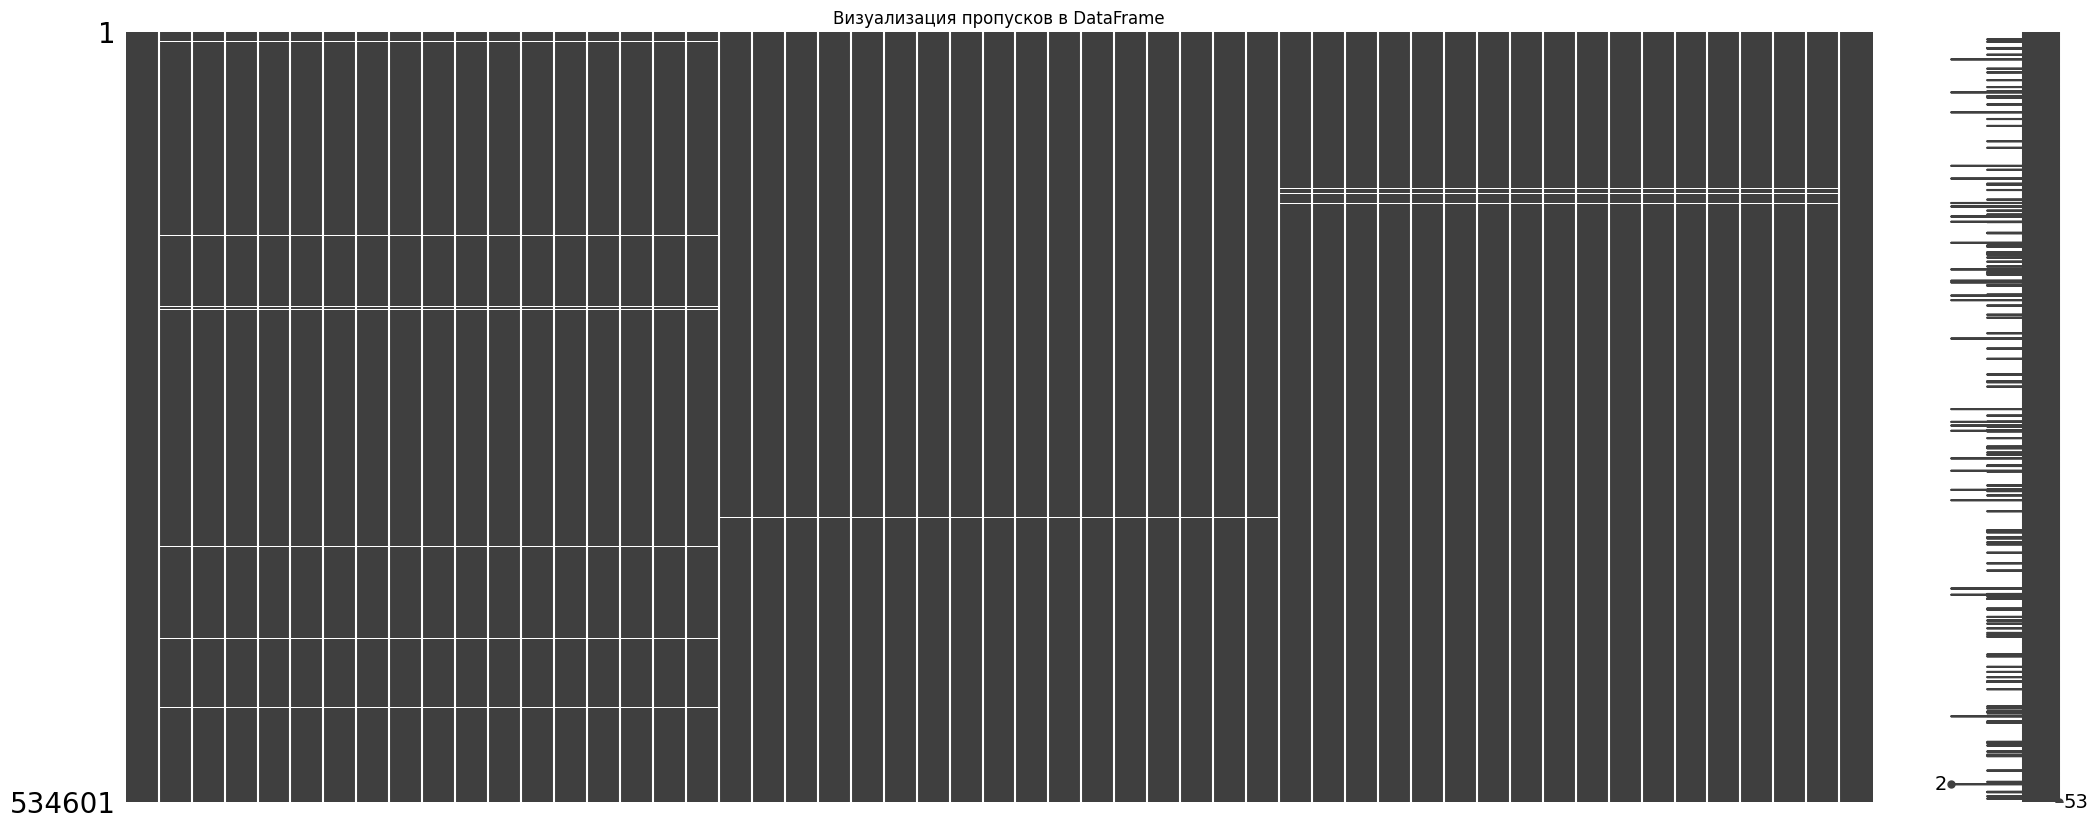

In [54]:
import missingno as msno

plt.figure(figsize=(10, 6))
msno.matrix(data)
plt.title('Визуализация пропусков в DataFrame')
plt.show()

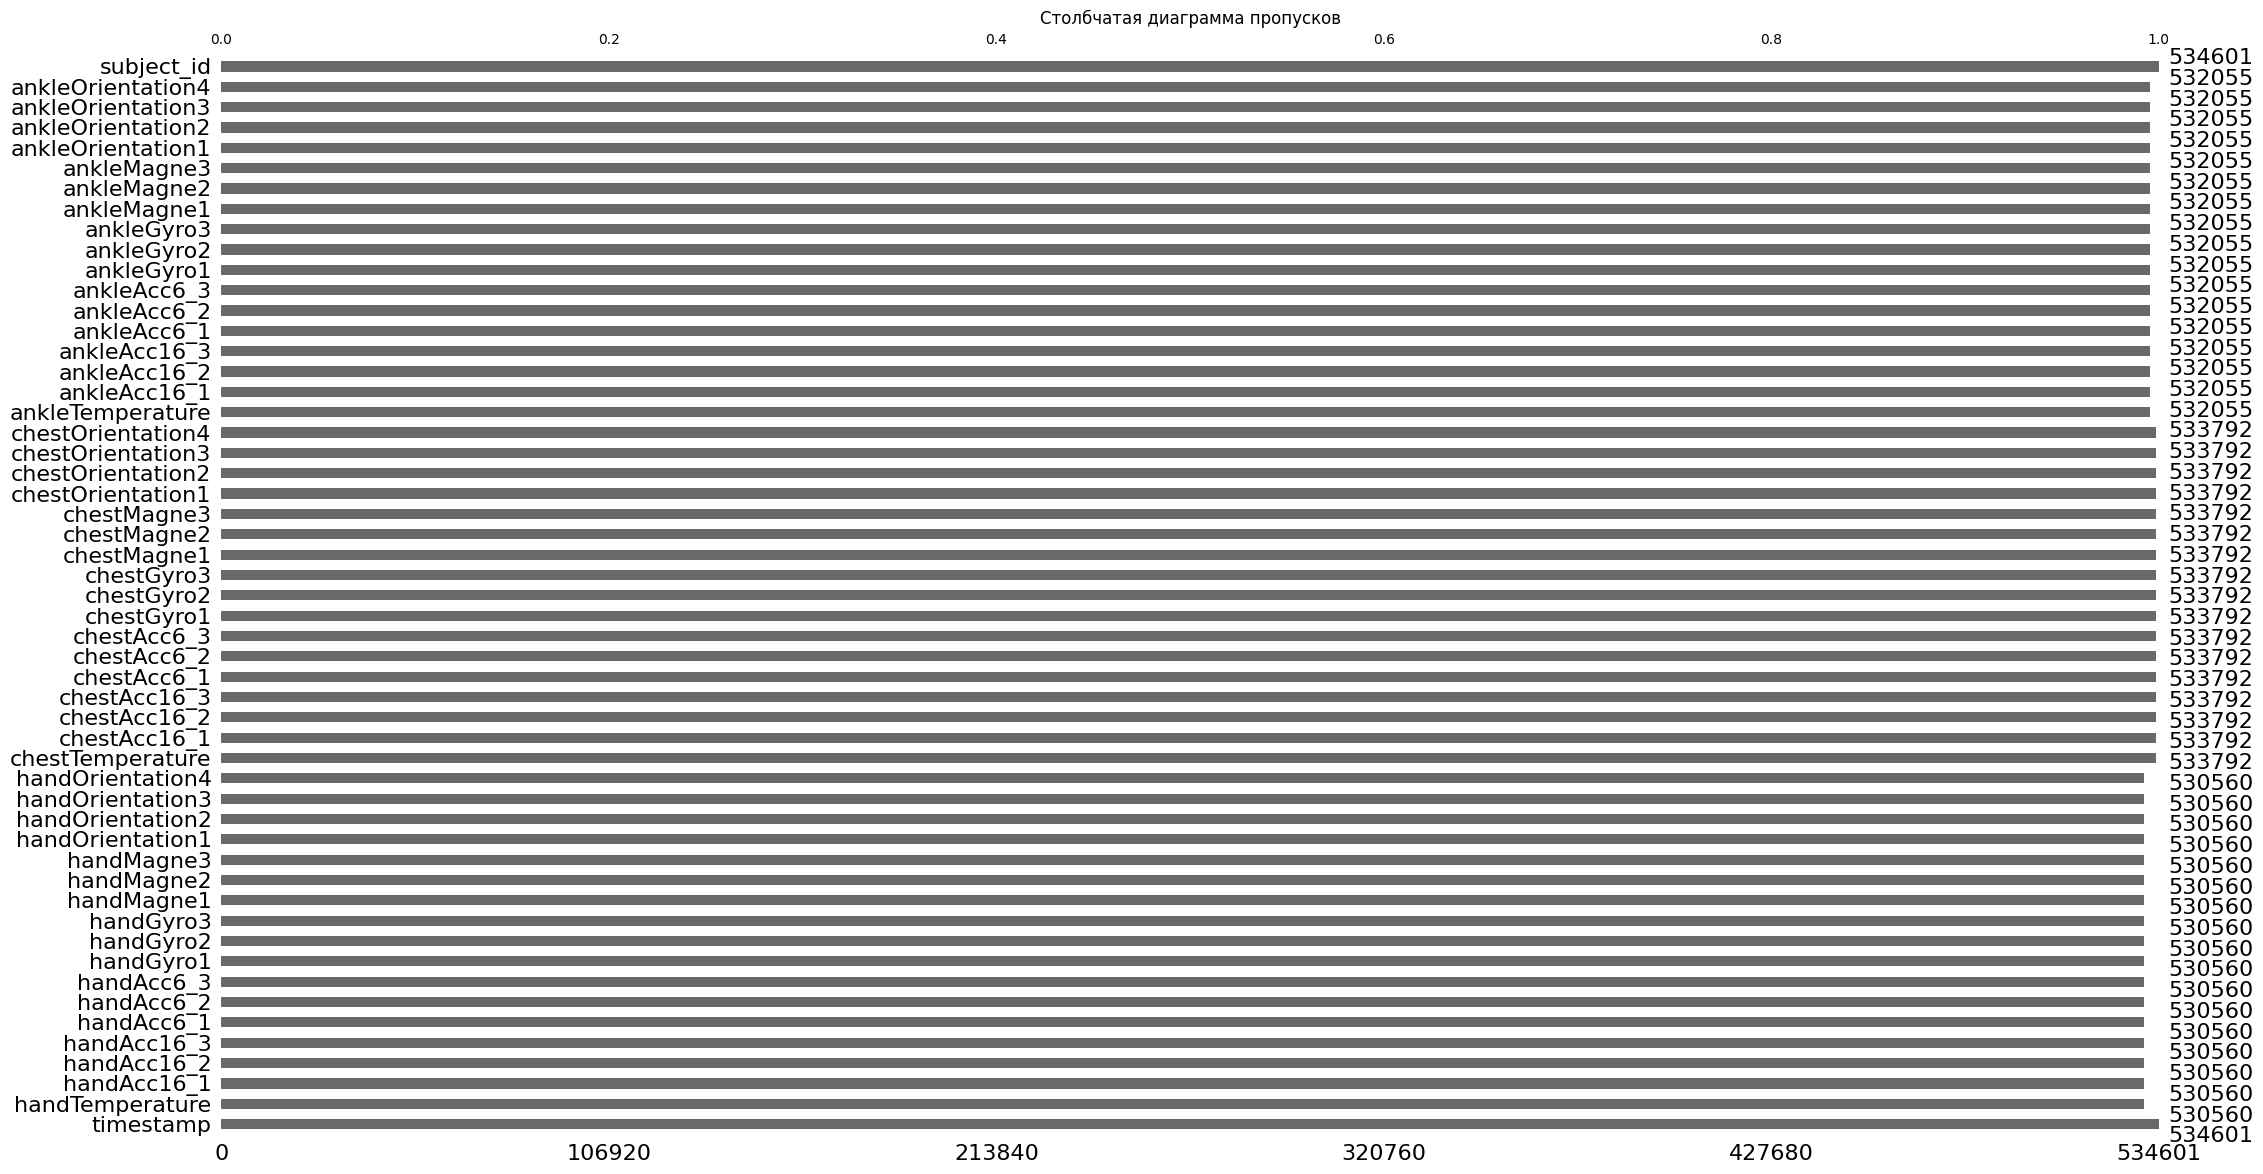

In [52]:
plt.figure(figsize=(12, 6))
plt.title('Столбчатая диаграмма пропусков')
msno.bar(data)
plt.show()

## Обработка пропусков

In [4]:
data = data.interpolate()
data.isna().sum()

timestamp            0
handTemperature      0
handAcc16_1          0
handAcc16_2          0
handAcc16_3          0
handAcc6_1           0
handAcc6_2           0
handAcc6_3           0
handGyro1            0
handGyro2            0
handGyro3            0
handMagne1           0
handMagne2           0
handMagne3           0
handOrientation1     0
handOrientation2     0
handOrientation3     0
handOrientation4     0
chestTemperature     0
chestAcc16_1         0
chestAcc16_2         0
chestAcc16_3         0
chestAcc6_1          0
chestAcc6_2          0
chestAcc6_3          0
chestGyro1           0
chestGyro2           0
chestGyro3           0
chestMagne1          0
chestMagne2          0
chestMagne3          0
chestOrientation1    0
chestOrientation2    0
chestOrientation3    0
chestOrientation4    0
ankleTemperature     0
ankleAcc16_1         0
ankleAcc16_2         0
ankleAcc16_3         0
ankleAcc6_1          0
ankleAcc6_2          0
ankleAcc6_3          0
ankleGyro1           0
ankleGyro2 

In [197]:
hand_columns = hand_columns.interpolate()

In [198]:
chest_columns = hand_columns.interpolate()

In [199]:
ankle_columns = hand_columns.interpolate()

## Визуализация распределения количественных переменных

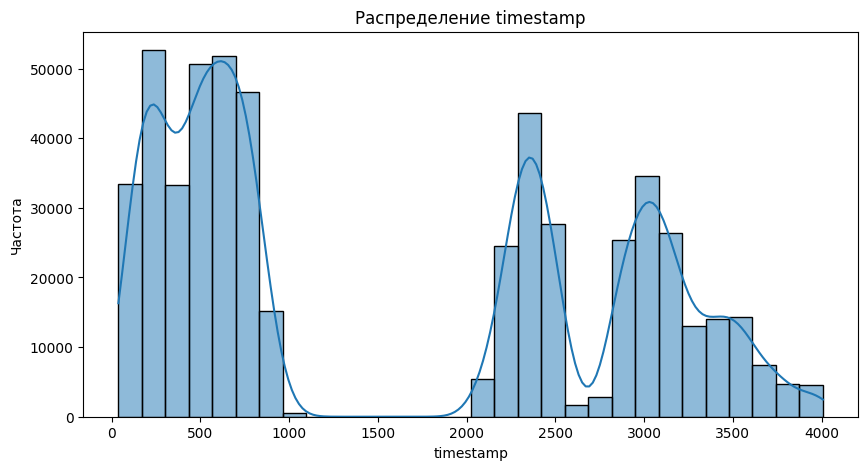

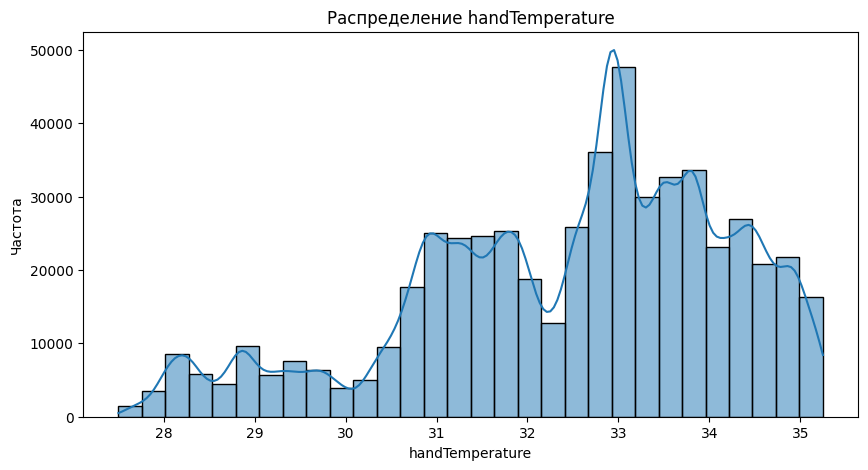

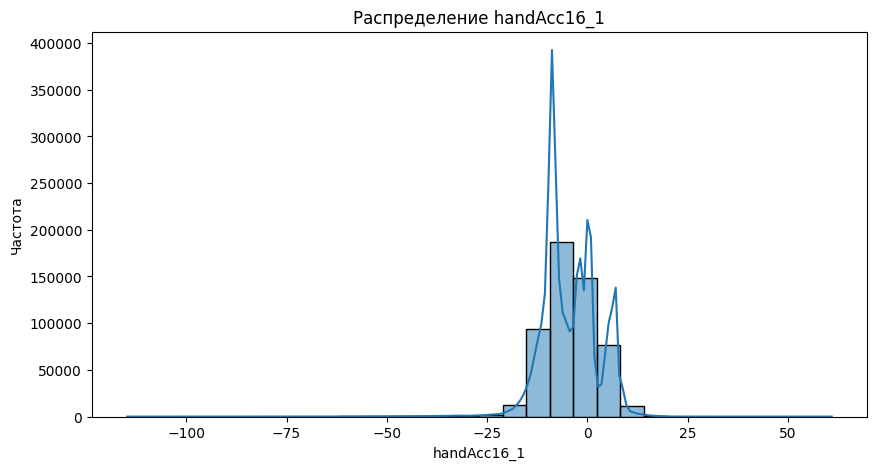

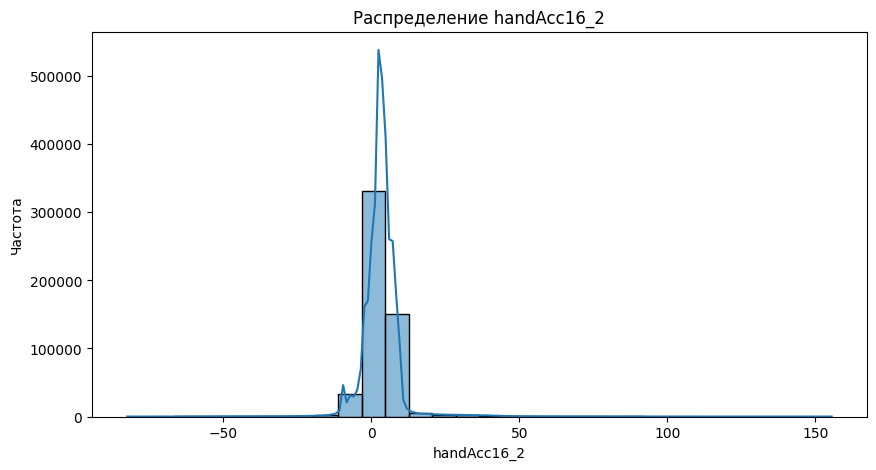

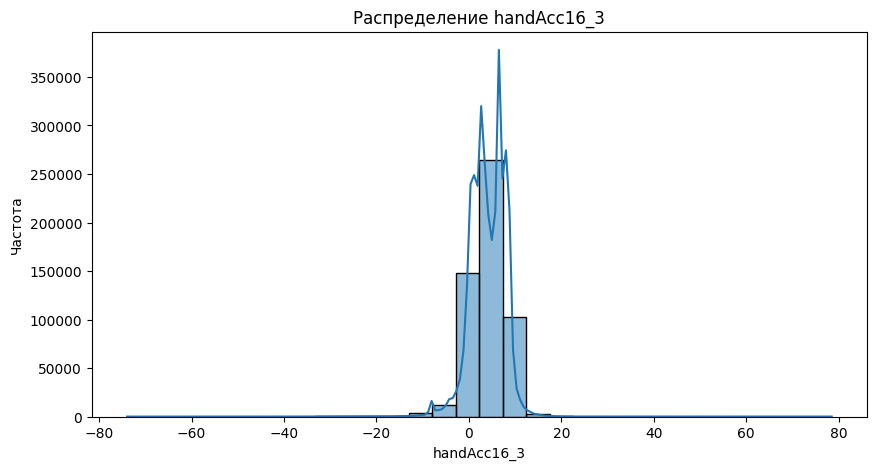

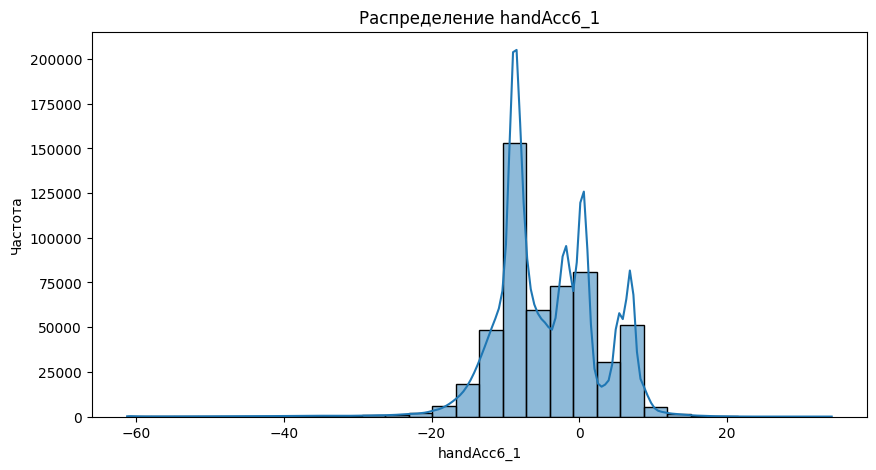

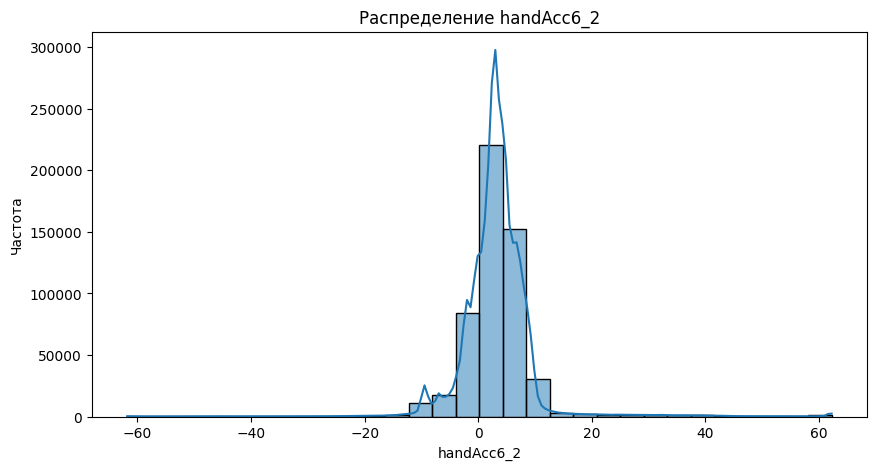

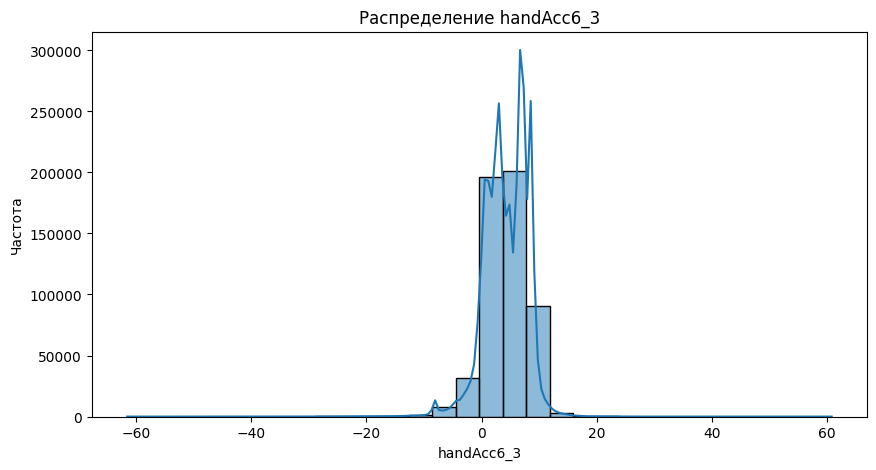

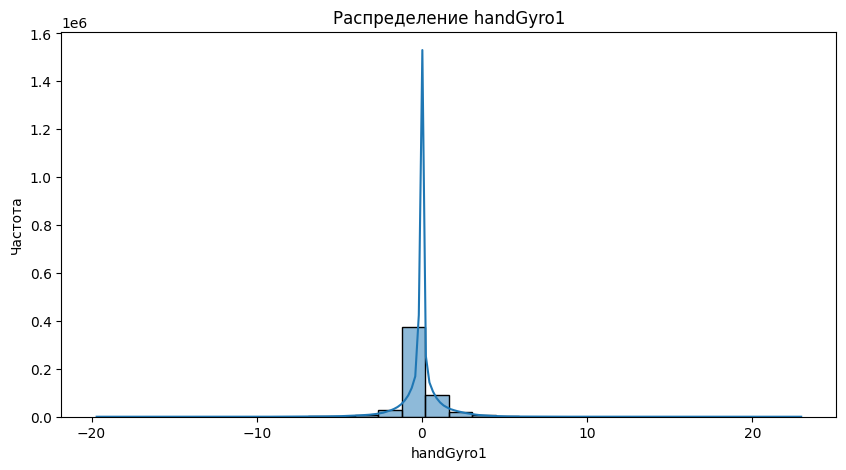

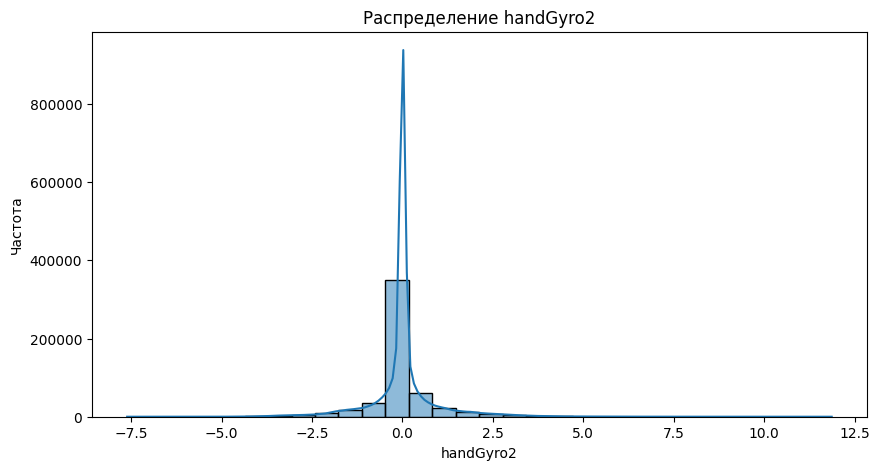

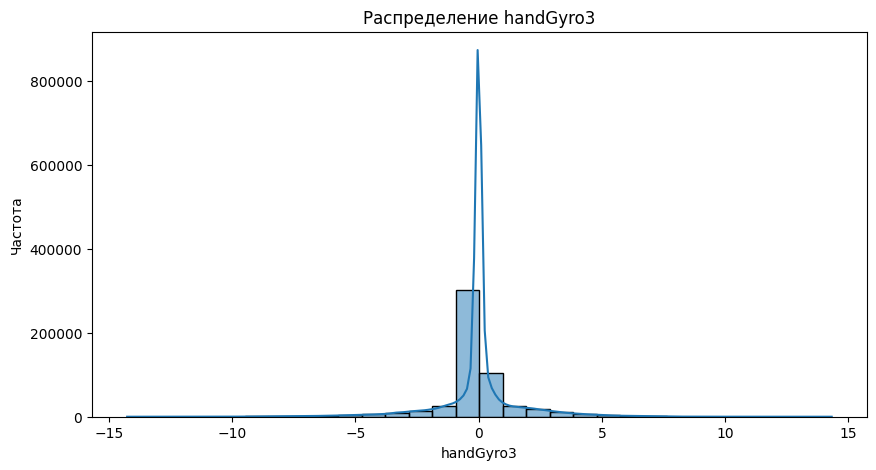

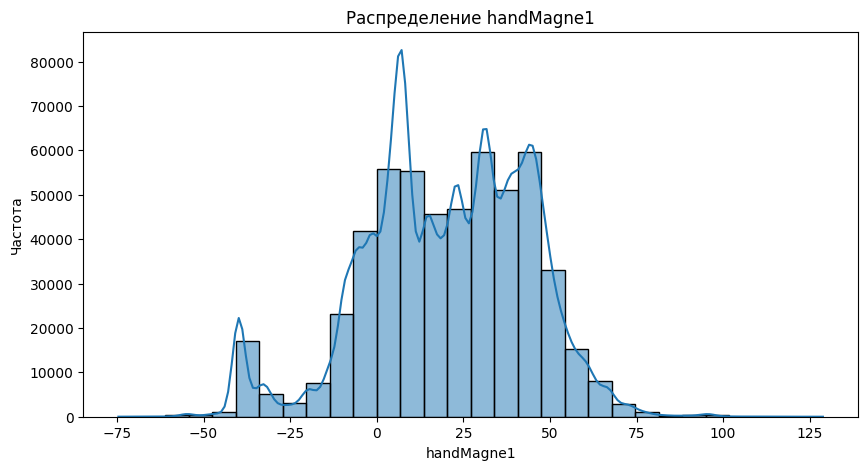

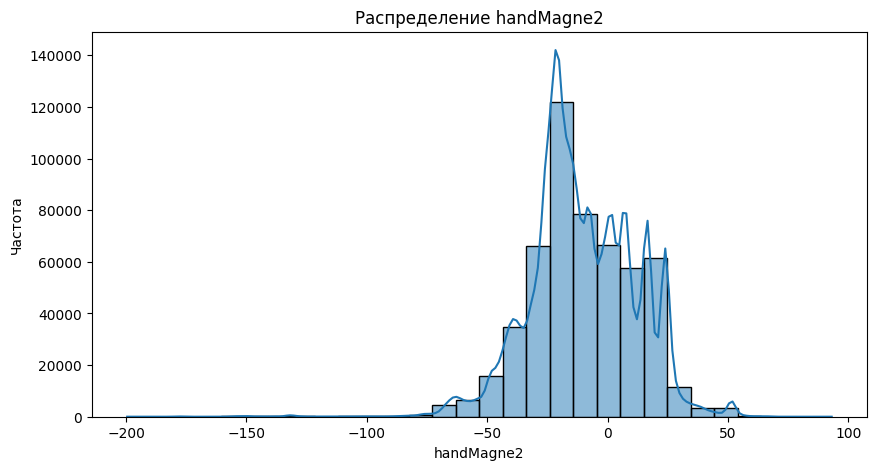

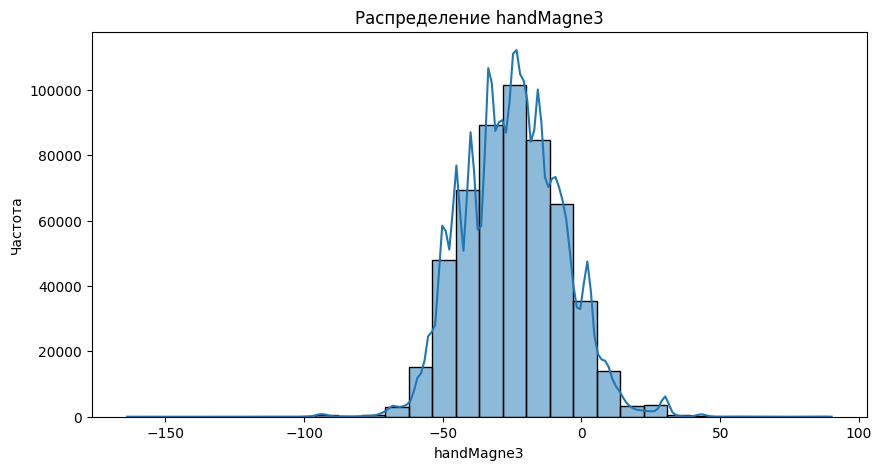

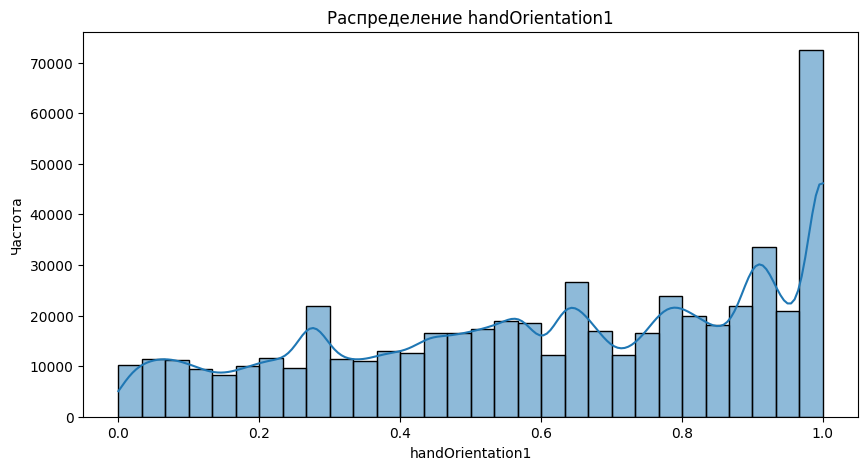

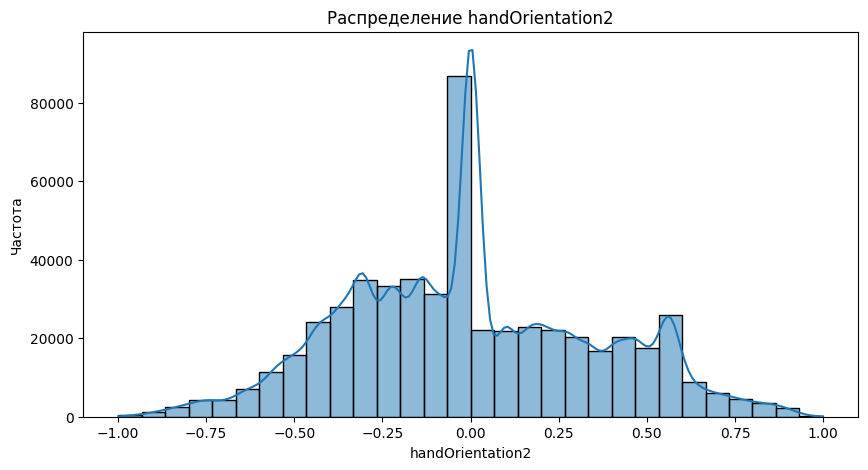

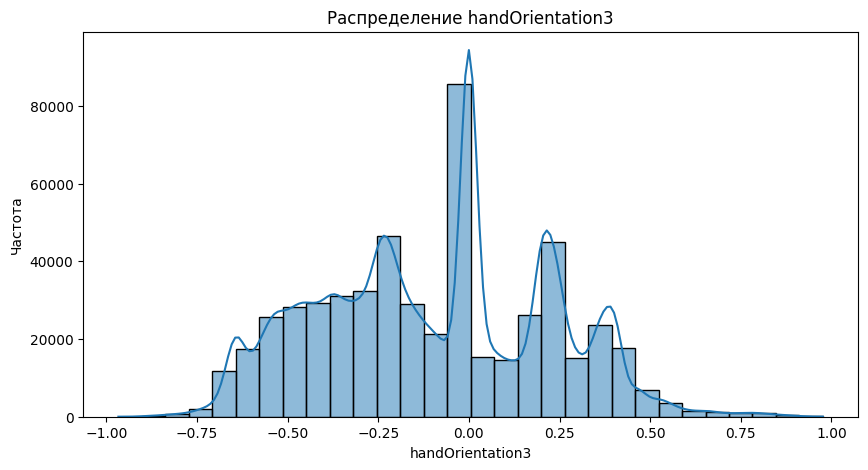

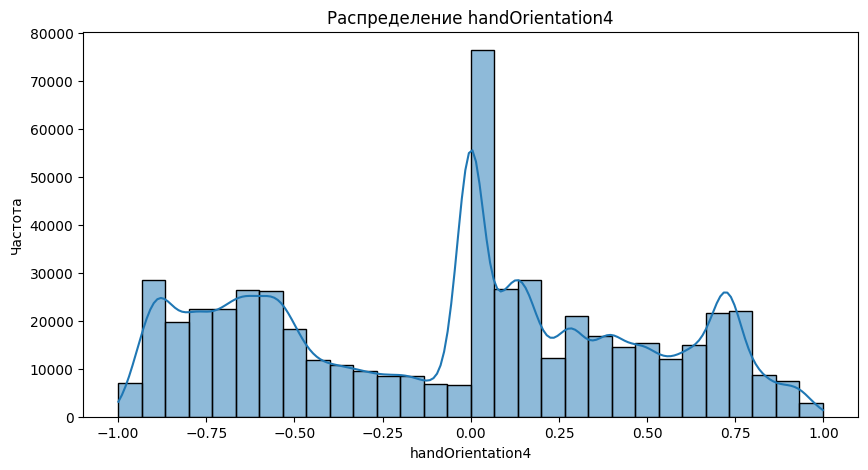

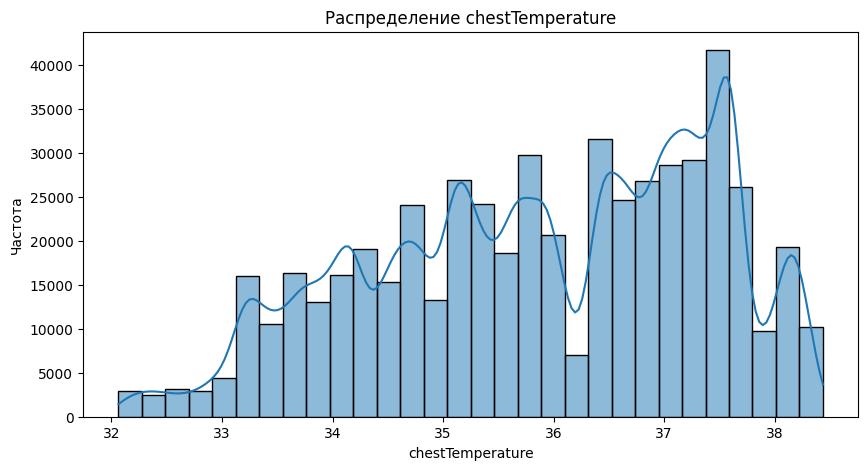

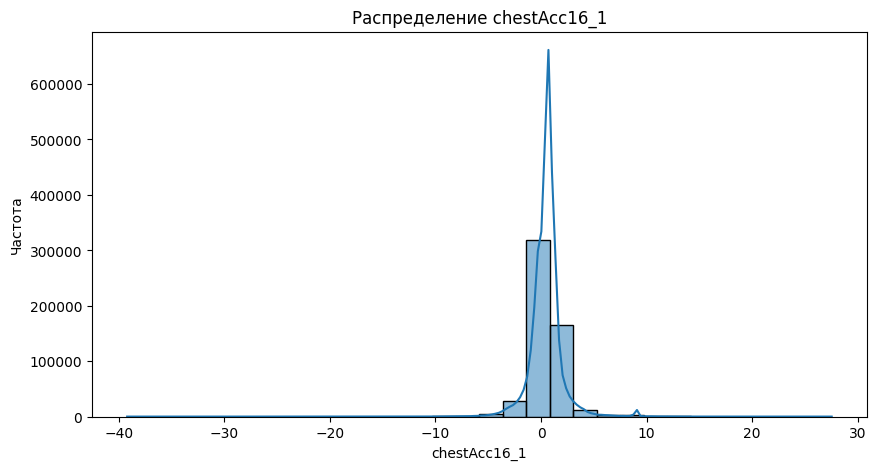

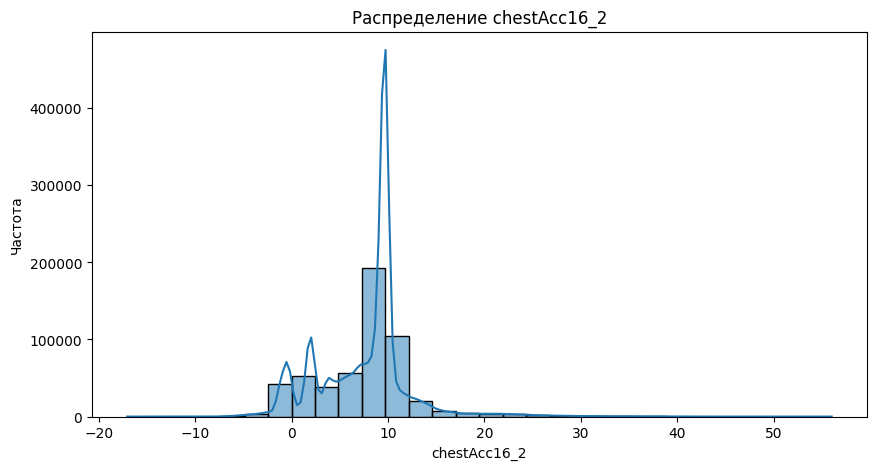

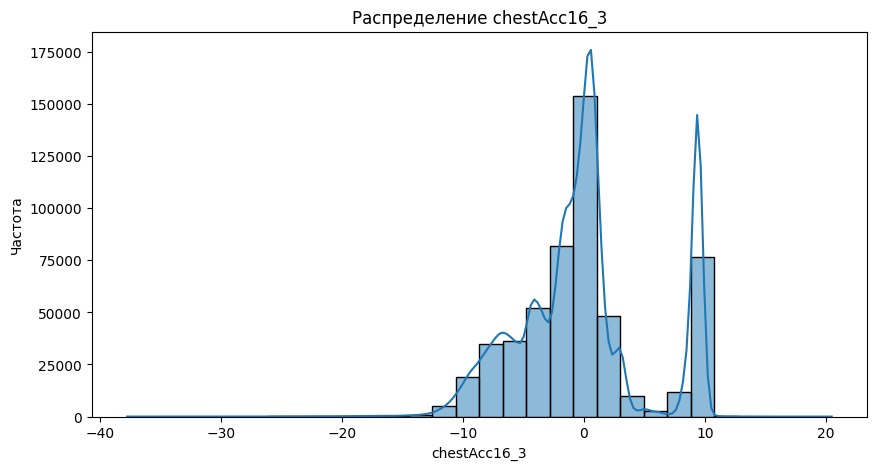

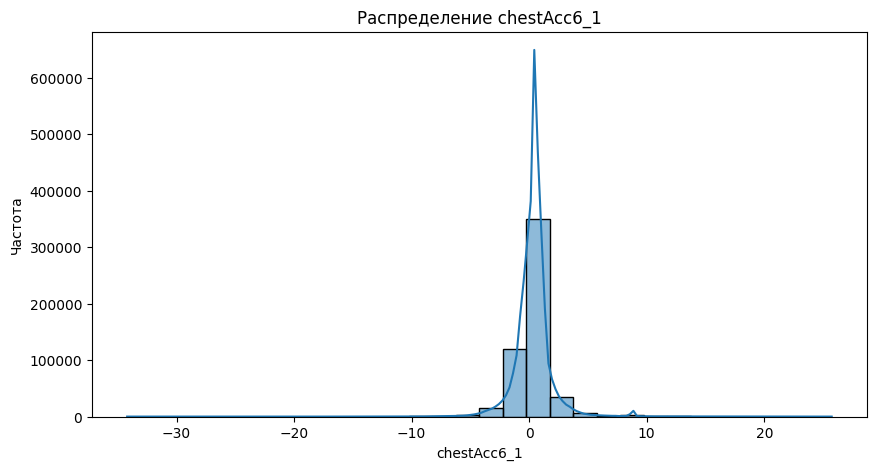

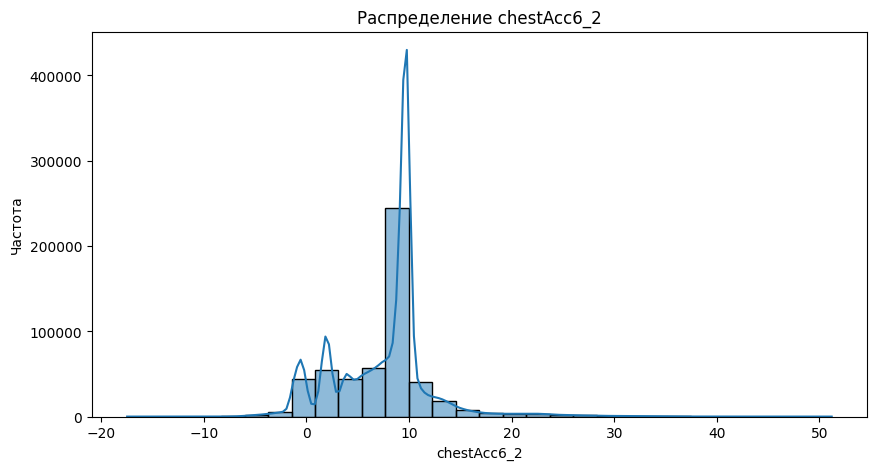

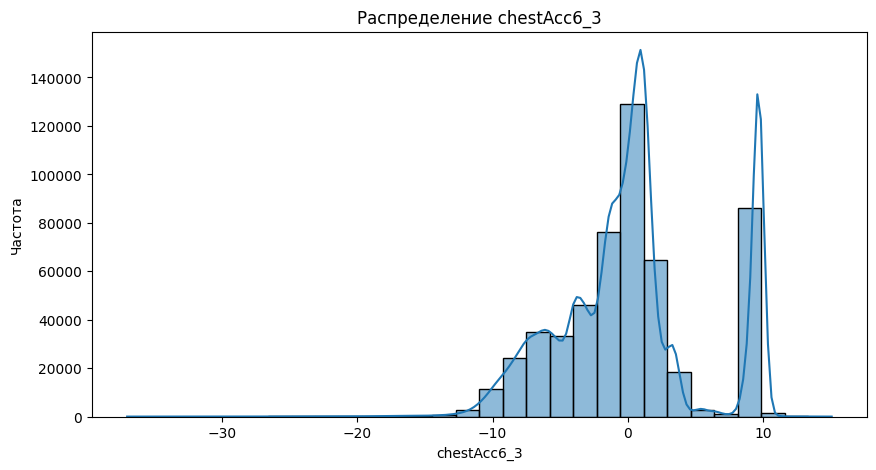

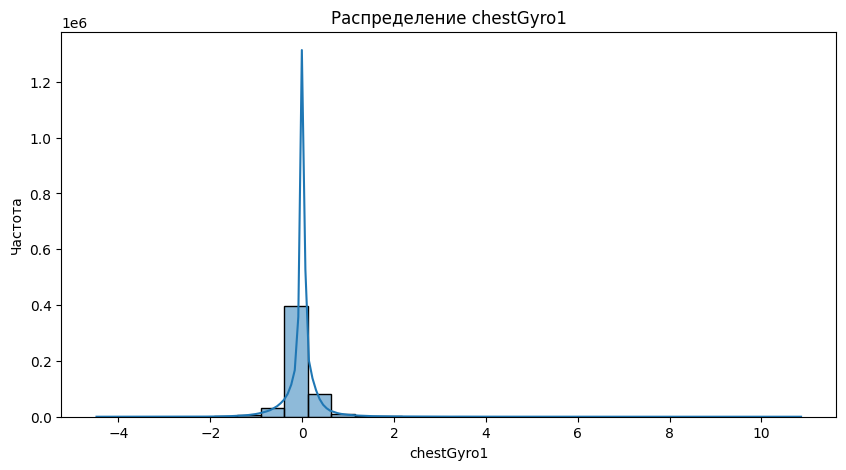

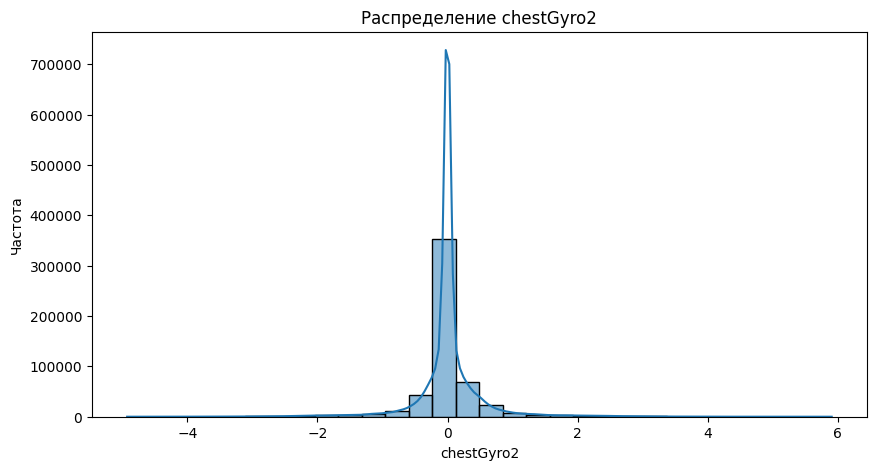

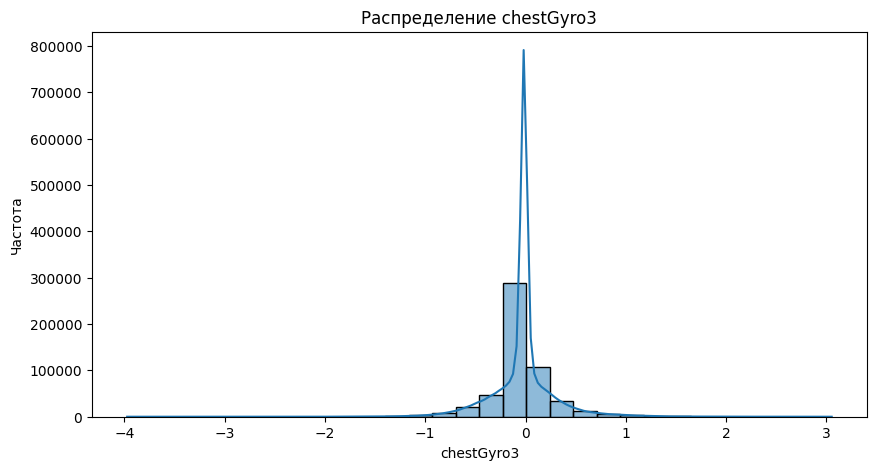

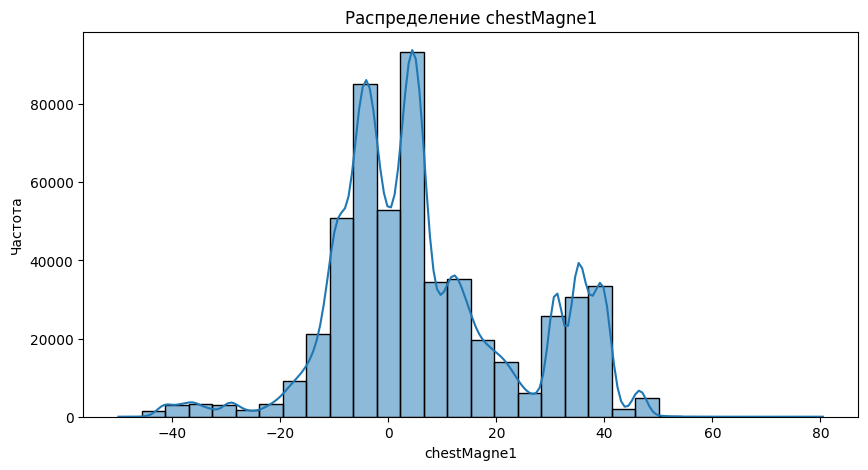

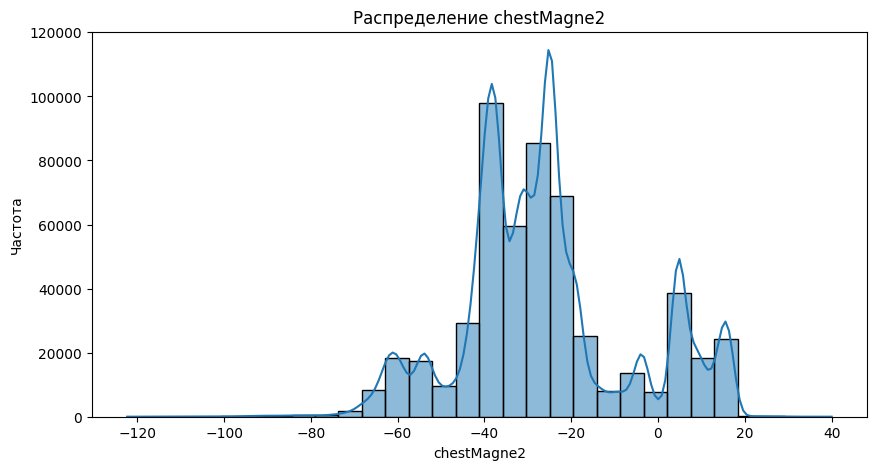

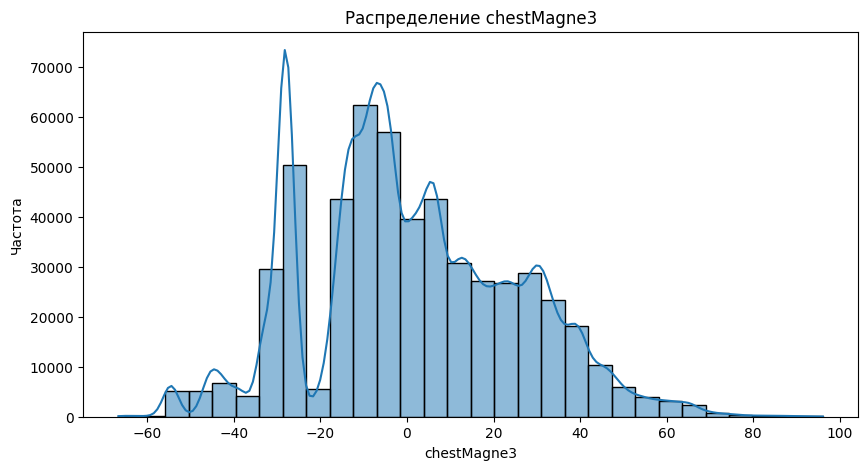

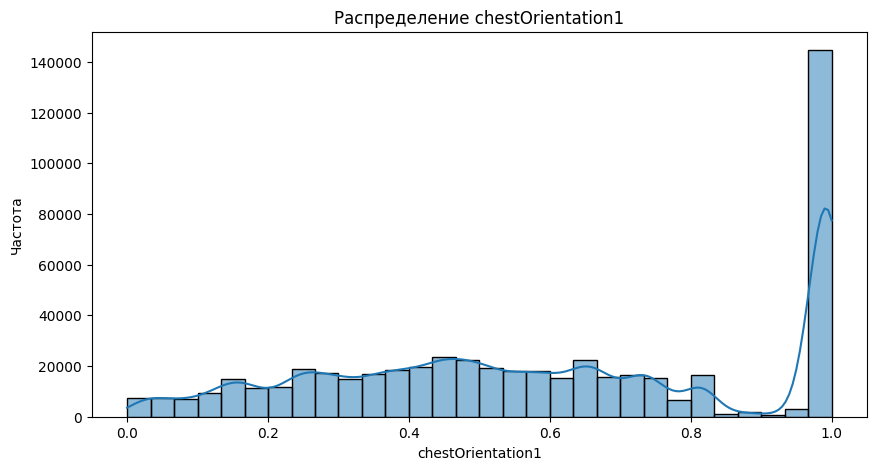

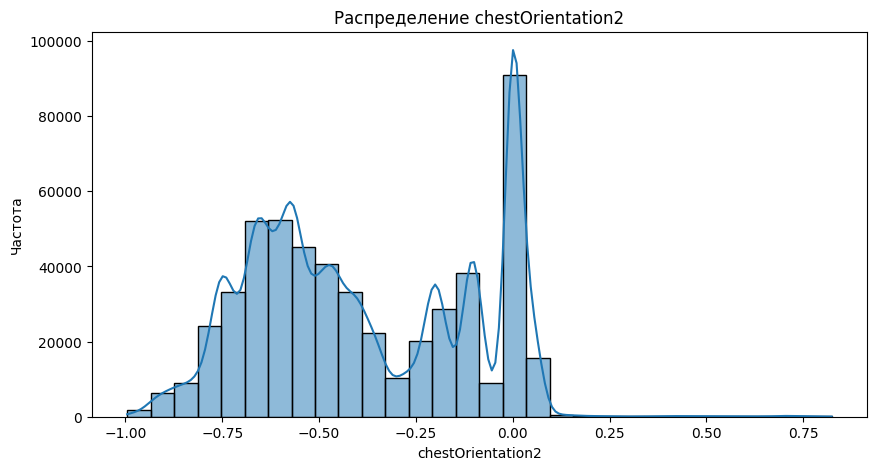

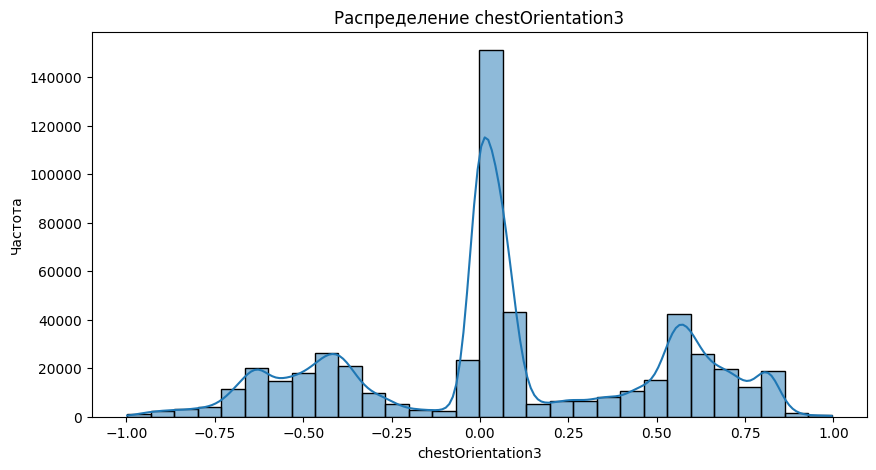

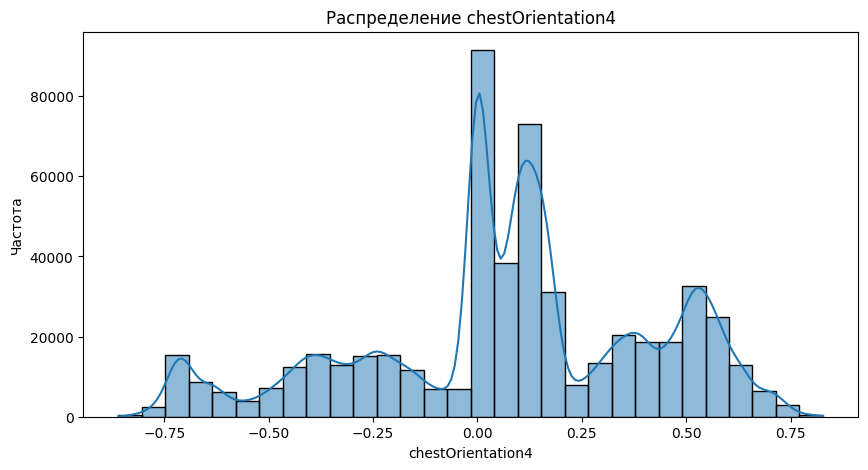

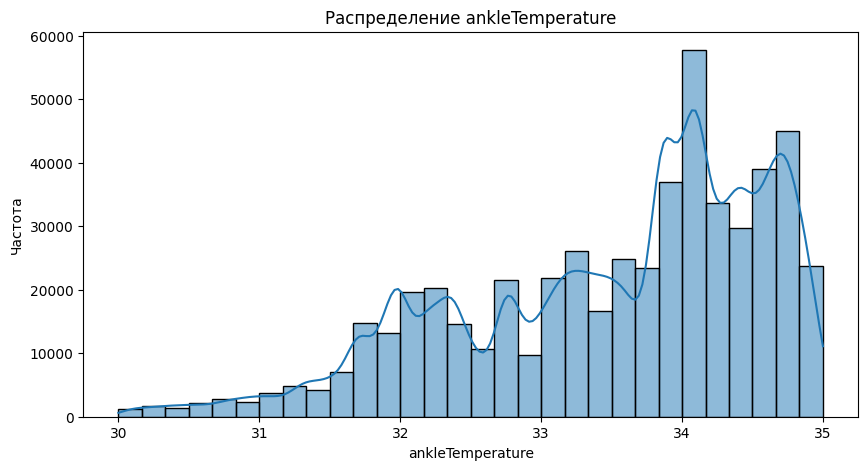

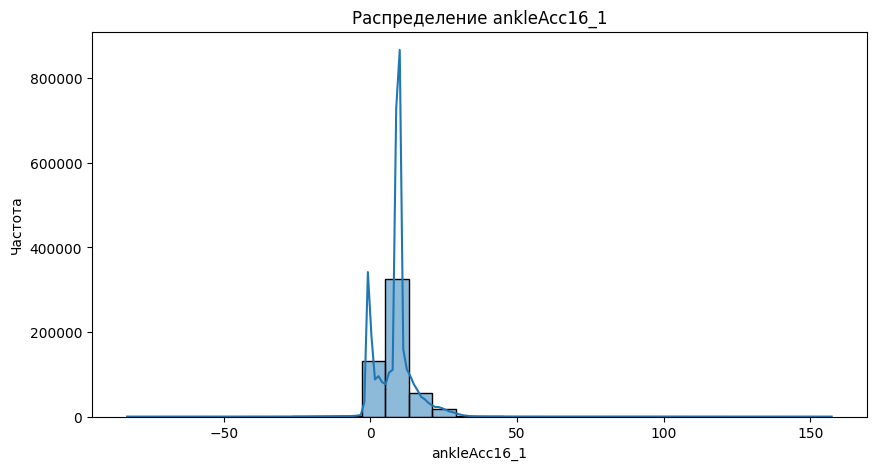

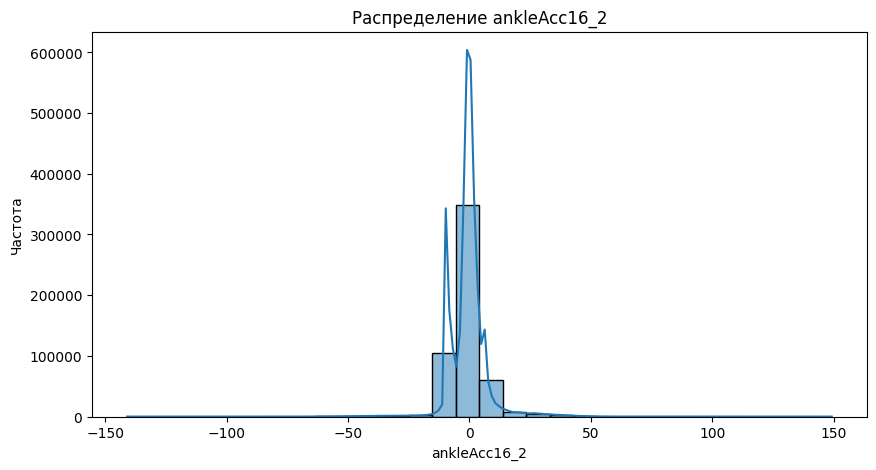

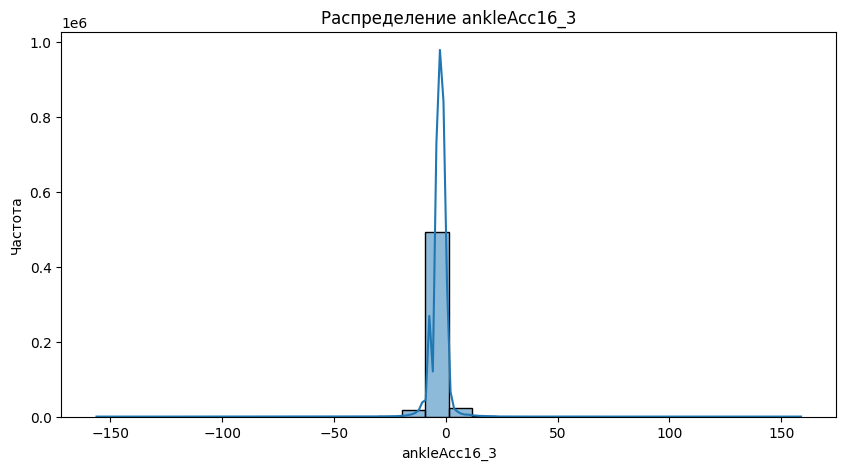

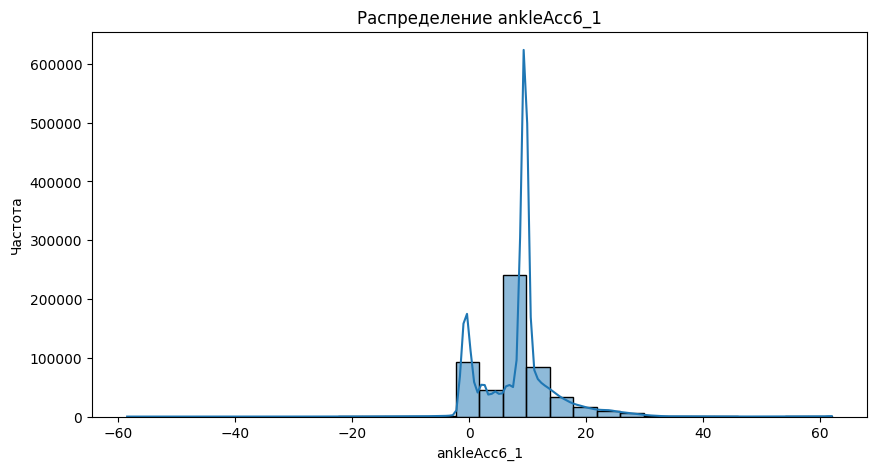

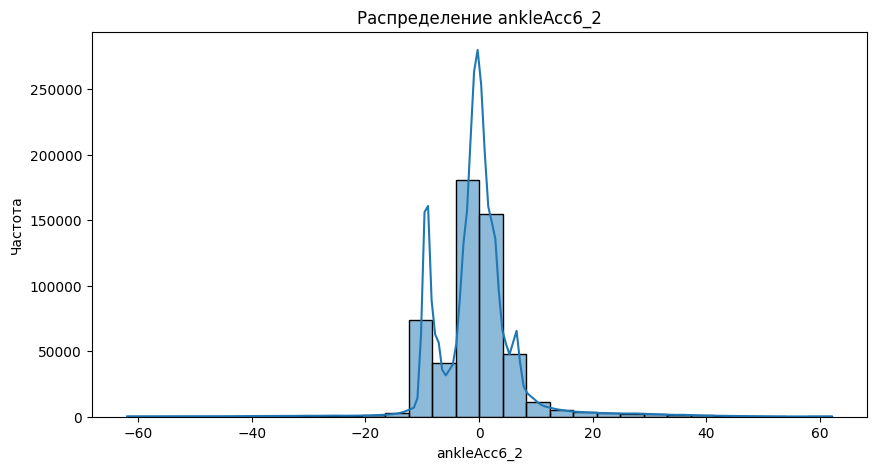

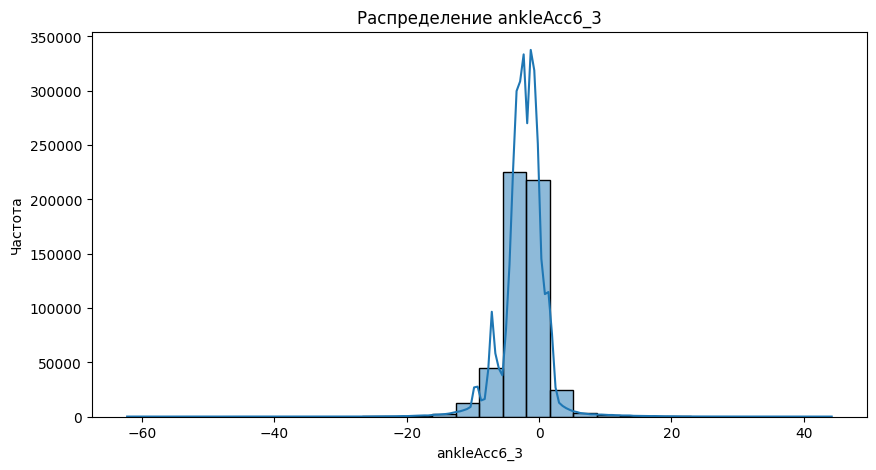

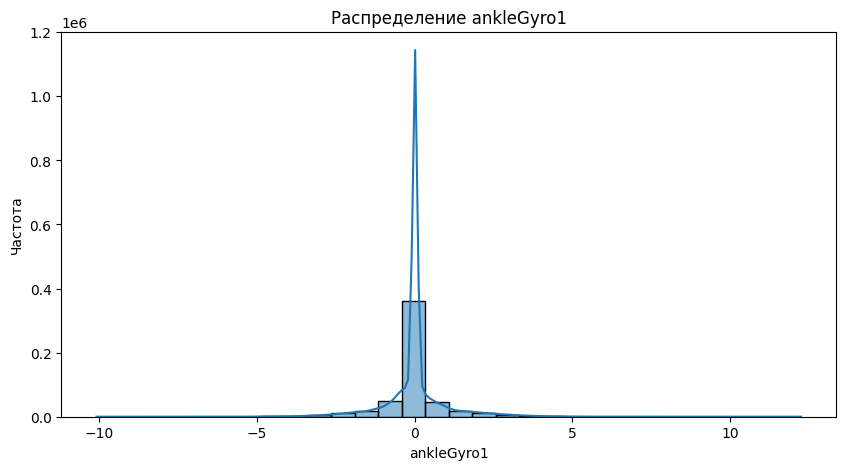

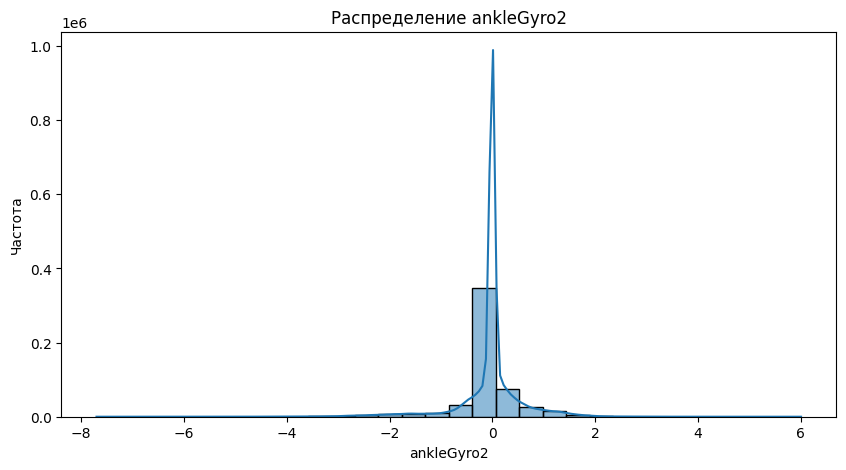

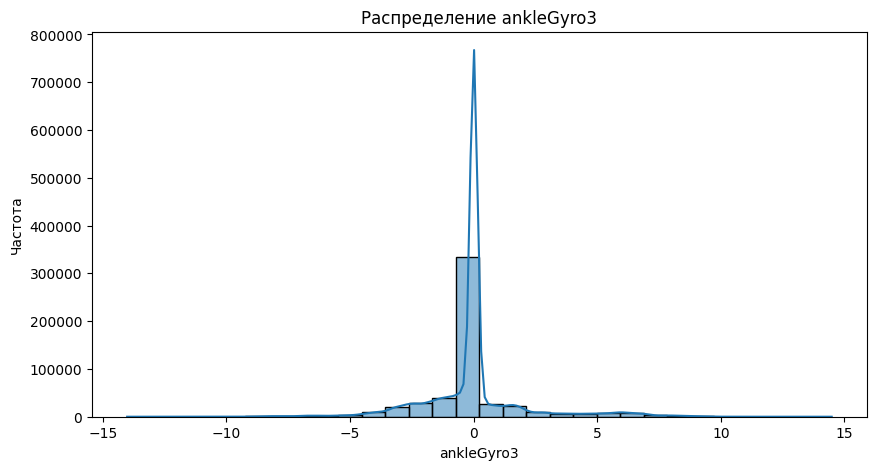

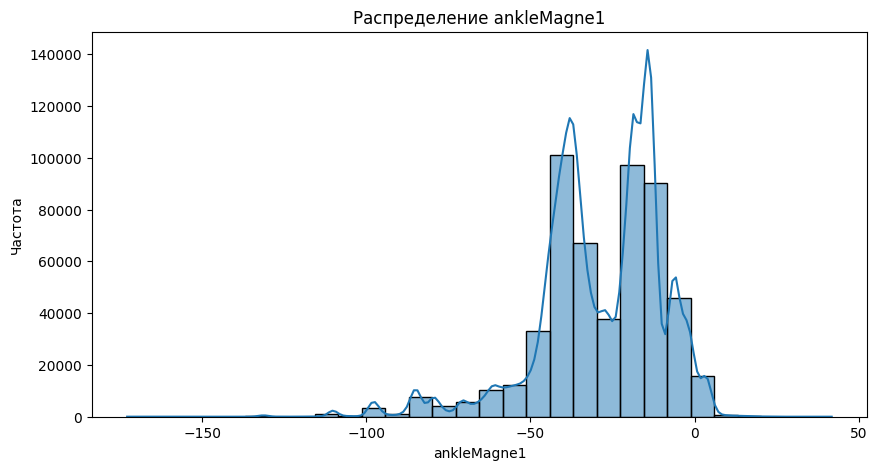

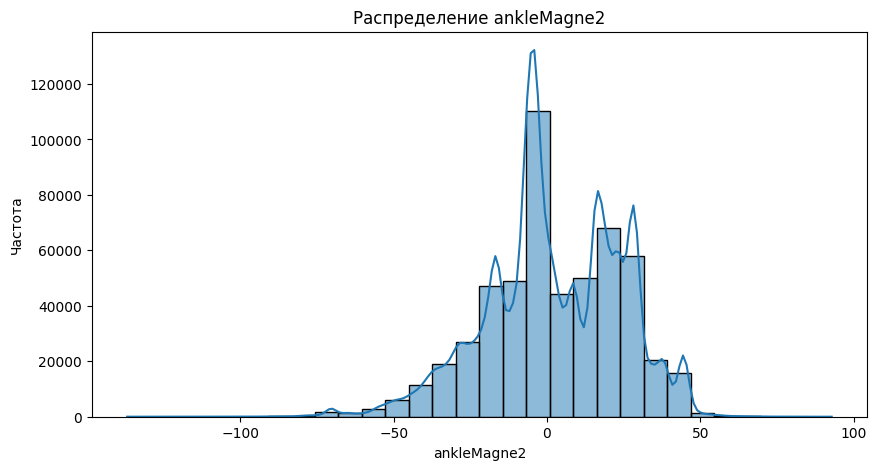

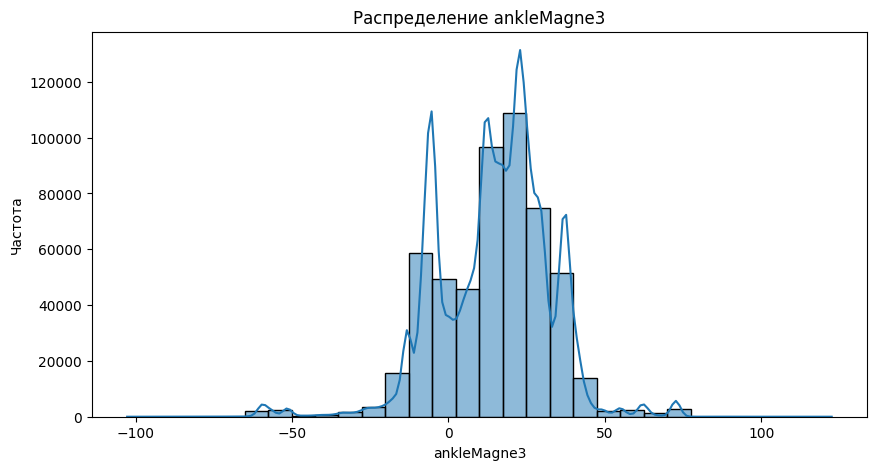

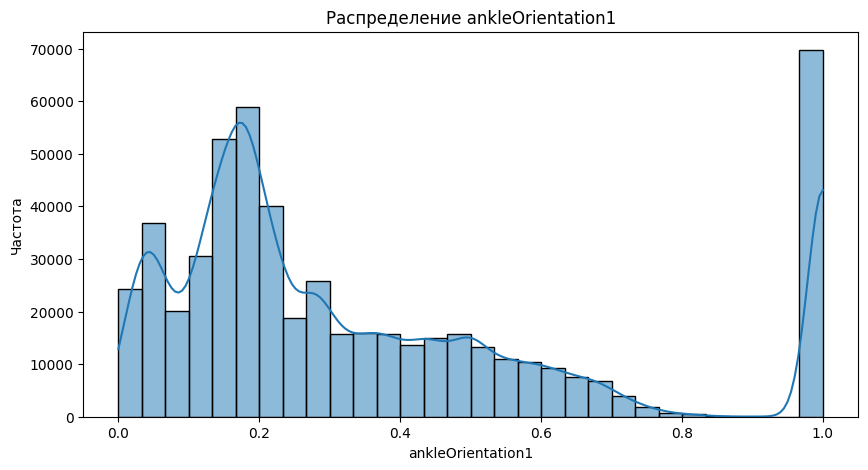

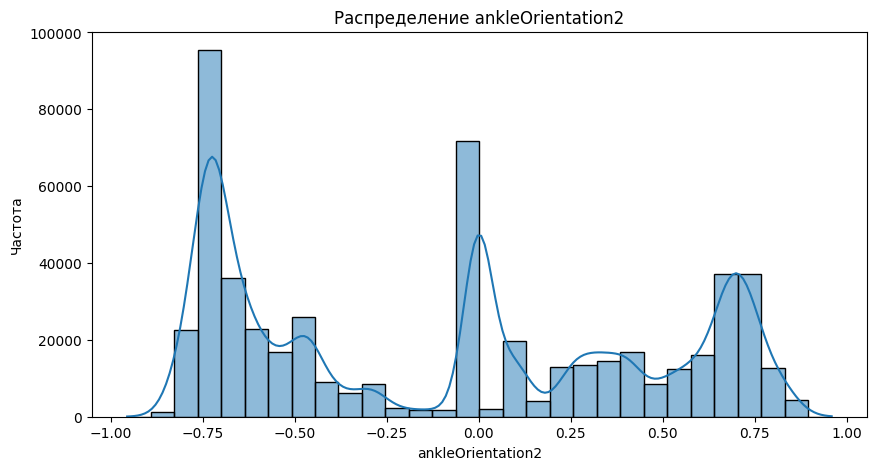

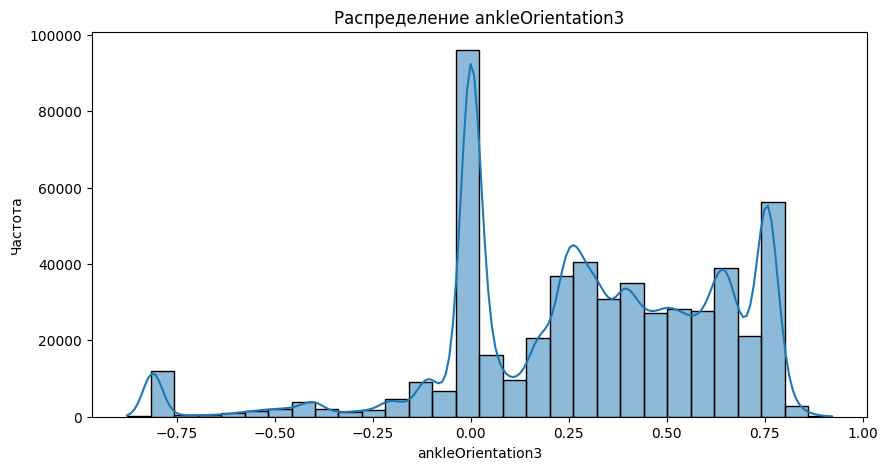

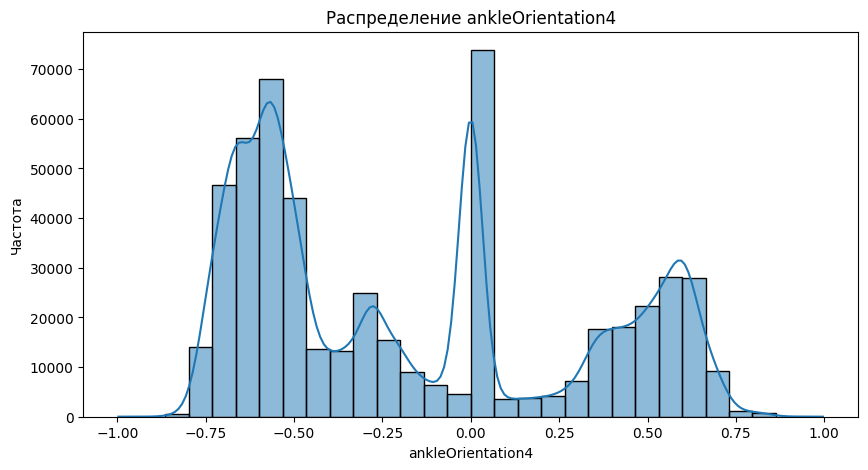

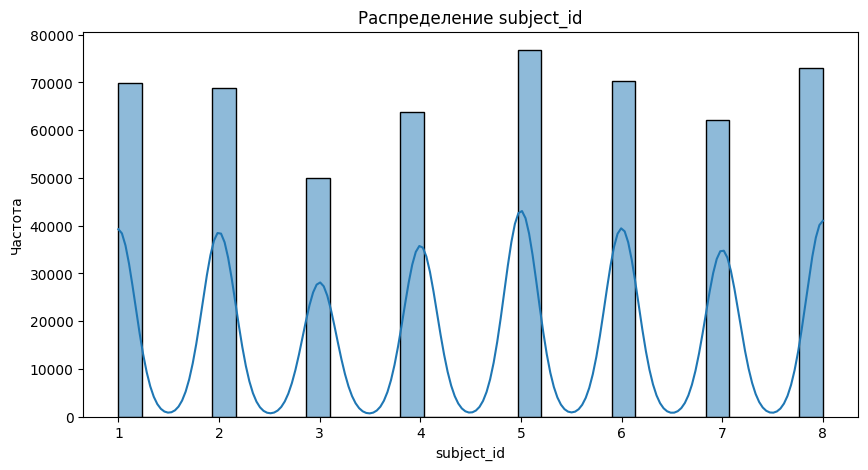

In [139]:
quantitative_columns = data.select_dtypes(include=['float64', 'int64']).columns

for column in quantitative_columns:
    plt.figure(figsize=(10, 5))
    sns.histplot(data[column], bins=30, kde=True)
    plt.title(f'Распределение {column}')
    plt.xlabel(column)
    plt.ylabel('Частота')
    plt.show()

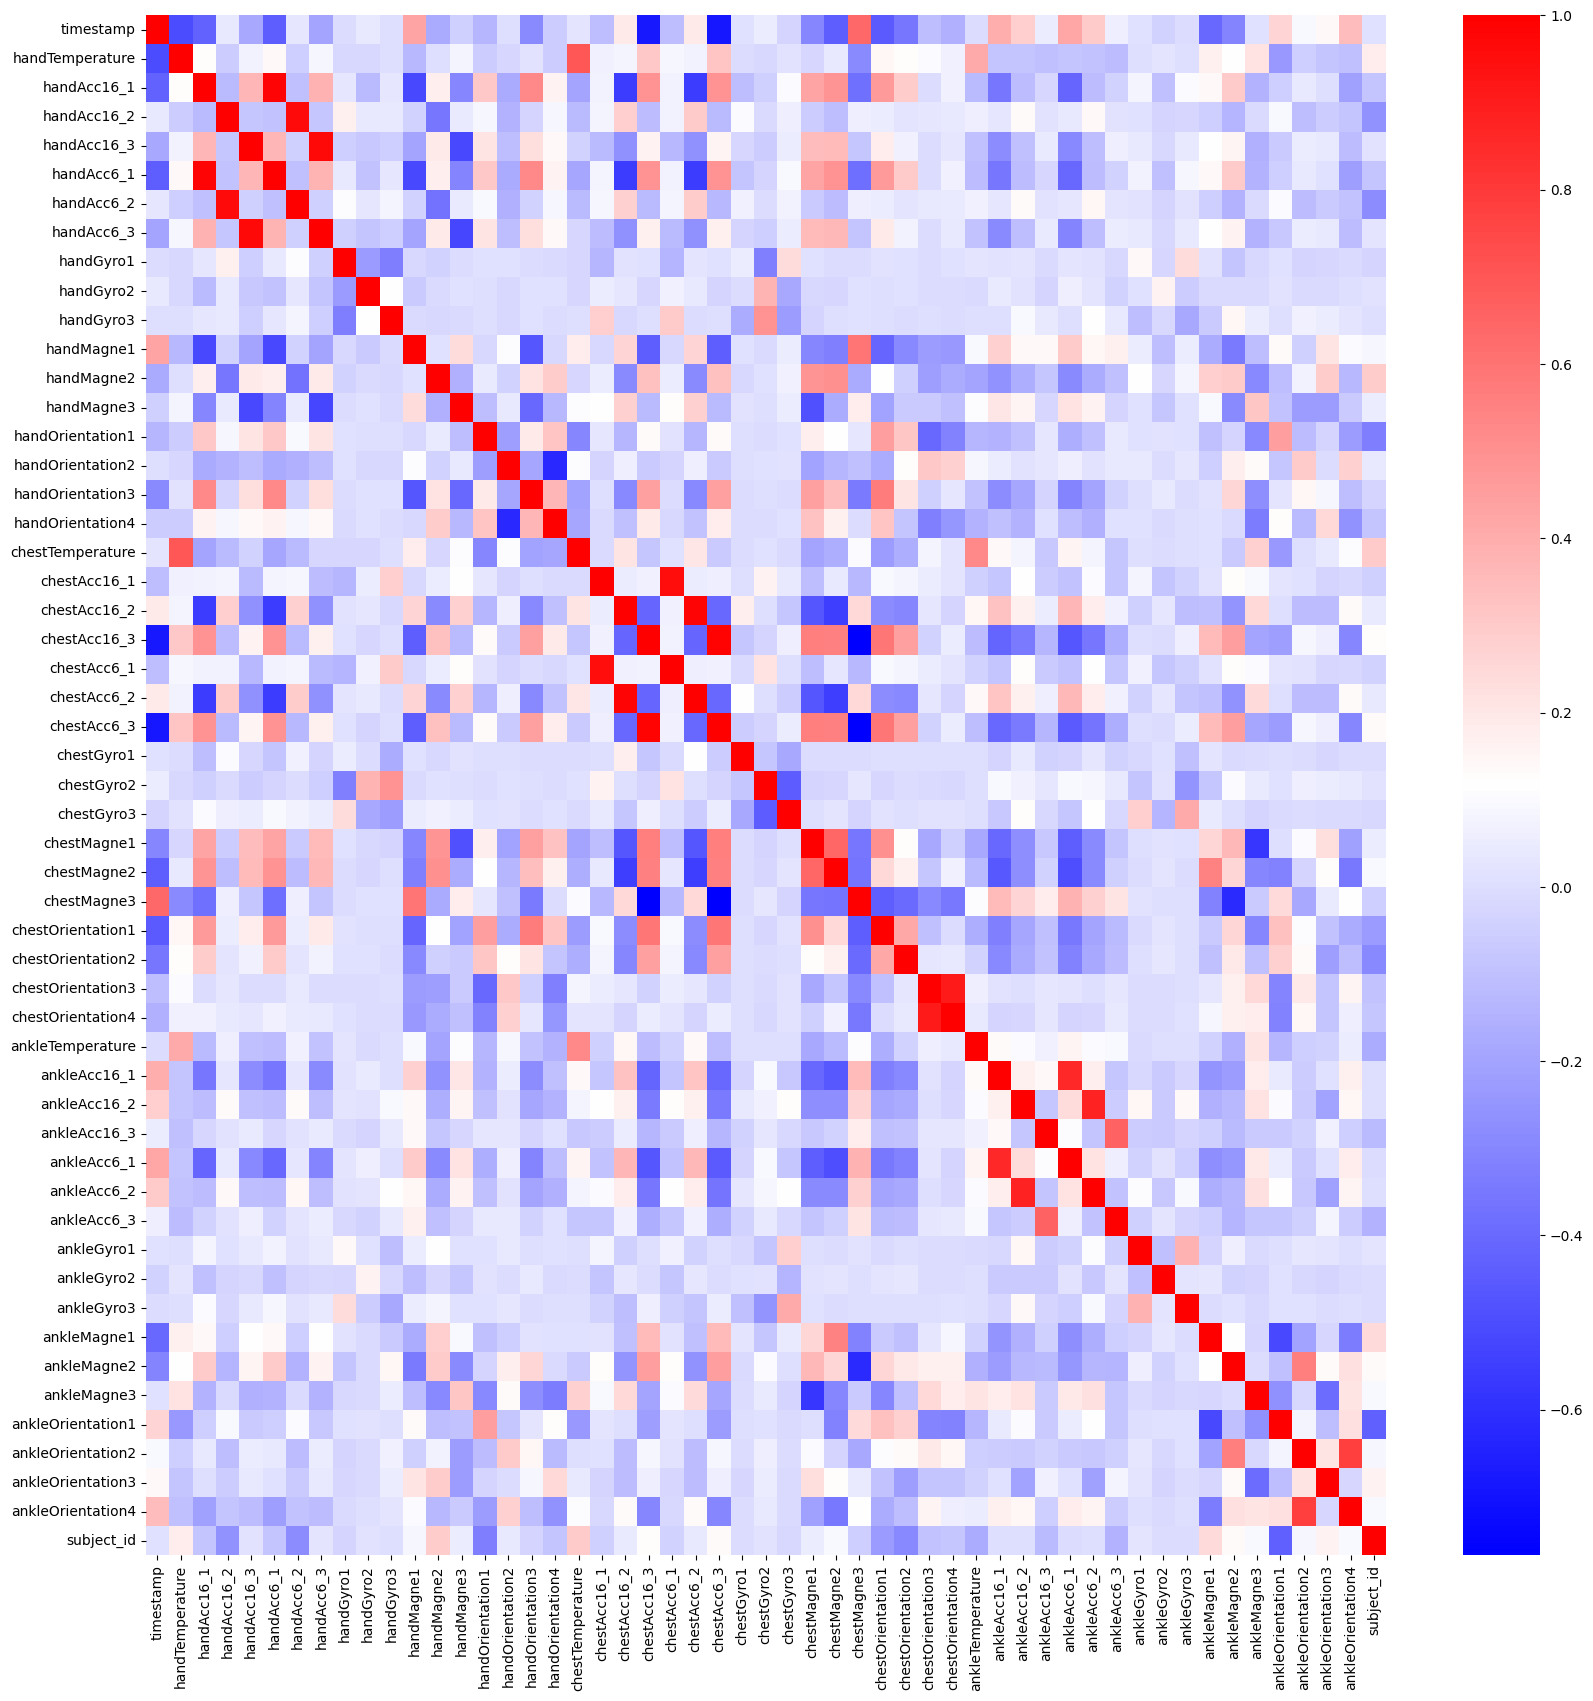

In [140]:
corr = data.corr()
f, ax = plt.subplots(figsize=(20, 20))
sns.heatmap(corr, mask=np.zeros_like(corr), cmap = "bwr",ax=ax)
plt.show()

## Масштабирование признаков

In [5]:
from sklearn.preprocessing import StandardScaler

data_std = StandardScaler().fit_transform(data)

scaled_data = pd.DataFrame(data_std, index = data.index, columns = data.columns)
scaled_data

,timestamp,handTemperature,handAcc16_1,handAcc16_2,handAcc16_3,handAcc6_1,handAcc6_2,handAcc6_3,handGyro1,handGyro2,...,ankleGyro2,ankleGyro3,ankleMagne1,ankleMagne2,ankleMagne3,ankleOrientation1,ankleOrientation2,ankleOrientation3,ankleOrientation4,subject_id
0,-1.077886,1.383760,0.757231,0.584776,0.510664,0.762694,0.616920,0.534955,-0.011434,-0.026646,...,0.010026,0.013753,0.737136,1.134555,-1.145553,-0.510941,0.786246,1.336797,-0.708140,0.190410
1,1.655200,-1.542161,0.051790,0.072016,1.098267,-0.226447,0.000586,0.693620,0.107743,-0.437495,...,-1.032808,0.877262,-0.210992,-0.804863,-0.896624,0.725106,-0.851330,0.297695,-0.536677,-1.103768
2,-0.875290,1.098304,0.344312,-1.781430,-0.864405,0.364464,-1.869295,-0.835905,0.024908,0.014511,...,0.035695,-0.004352,0.515551,0.638528,0.590981,-0.732416,1.373972,0.262530,1.674988,1.484589
3,0.971193,-0.293292,-1.252472,0.362269,-0.831548,-1.309192,0.393529,-0.897058,1.489085,-0.085672,...,-0.213025,-1.720091,0.104544,1.450536,0.369273,0.186609,1.565125,0.008559,1.114097,-1.103768
4,-0.926540,0.598757,0.627159,0.752136,0.083334,0.640523,0.780732,0.146643,0.001532,-0.039074,...,0.005874,-0.002954,0.569350,-0.275132,-0.208420,-0.628202,-1.176374,-0.146954,-0.890970,0.621803
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
534596,1.516186,0.812849,-0.659715,0.202325,-0.310987,-0.753307,0.519869,-0.075309,-0.128408,0.805766,...,0.738288,-0.422473,0.194368,-1.155074,0.497191,-0.139528,-1.093288,0.733590,-0.296111,0.190410
534597,0.687313,1.044781,-0.466995,0.037284,-0.400220,-0.517513,0.195118,-0.254573,0.028656,0.193082,...,-2.808538,-1.501461,-0.360189,1.335589,0.094996,0.251696,1.345437,0.198171,1.414949,0.190410
534598,0.712516,1.276714,-0.274276,-0.127756,-0.489454,-0.281719,-0.129634,-0.433837,0.185719,-0.419602,...,-0.003788,-0.198810,-1.085757,0.831770,-0.874481,0.669670,0.696299,1.318086,0.699344,0.190410
534599,1.482655,-2.505574,1.404064,0.997765,-3.439181,1.803451,0.371647,-2.727570,3.067928,2.949408,...,0.621058,-2.744020,-0.279940,-0.593700,1.398596,-0.990360,-1.266513,-1.047464,-0.906017,0.621803


In [6]:
from sklearn.decomposition import PCA

pca = PCA(n_components = 15)

principalComponents = pca.fit_transform(scaled_data)

principalData = pd.DataFrame(data = principalComponents)

In [7]:
principalData

,0,1,2,3,4,5,6,7,8,9,10,11,12,13,14
0,5.946109,0.364297,-0.173208,-0.853926,0.262714,-0.539950,-0.779423,-0.157257,1.759542,0.456760,0.897617,1.520298,-0.626248,-0.585089,0.189818
1,-1.155907,-4.236407,-1.788424,0.157810,-0.853420,0.577810,2.763084,-0.817617,-0.686467,-0.502126,-0.593032,0.539713,-0.814594,-1.348079,0.500823
2,0.261861,2.906660,-2.048030,0.846311,0.823733,1.499587,-0.805782,0.938396,0.435055,0.466870,0.499418,-0.917642,-0.208495,1.606696,1.685184
3,-3.827059,1.148078,-0.049818,1.709193,-1.350799,0.667901,0.057444,-2.057719,0.042570,2.910965,0.028331,0.070327,0.248420,0.102481,1.019325
4,0.736508,-0.136346,1.206942,-2.239696,-0.065524,-0.565373,1.007924,0.323588,0.912312,-0.260916,1.321784,-0.597514,0.114459,0.071310,0.389338
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
534596,-3.066955,-1.106519,0.571786,-1.058709,4.206519,-1.064162,1.436877,1.718608,1.263416,-0.915577,3.062338,0.537561,0.759880,0.461156,-1.713859
534597,-1.398291,3.182467,1.595631,1.955506,0.235209,3.199405,0.323267,-0.719256,2.970315,0.330544,-0.158915,-0.275330,-0.572437,-3.210379,-1.515455
534598,-0.941498,1.889796,-0.969211,2.067463,0.584273,-0.714909,-0.619927,0.683698,1.094694,1.102249,0.564584,1.323846,-1.461827,-1.155248,0.718133
534599,-5.169027,1.456140,5.813303,-0.799240,2.908094,-1.204834,-0.541905,-1.905557,0.262637,-4.630289,-1.265721,-2.336510,-1.570017,0.683622,3.610353


## Матрица корреляции после изменений:

<Axes: >

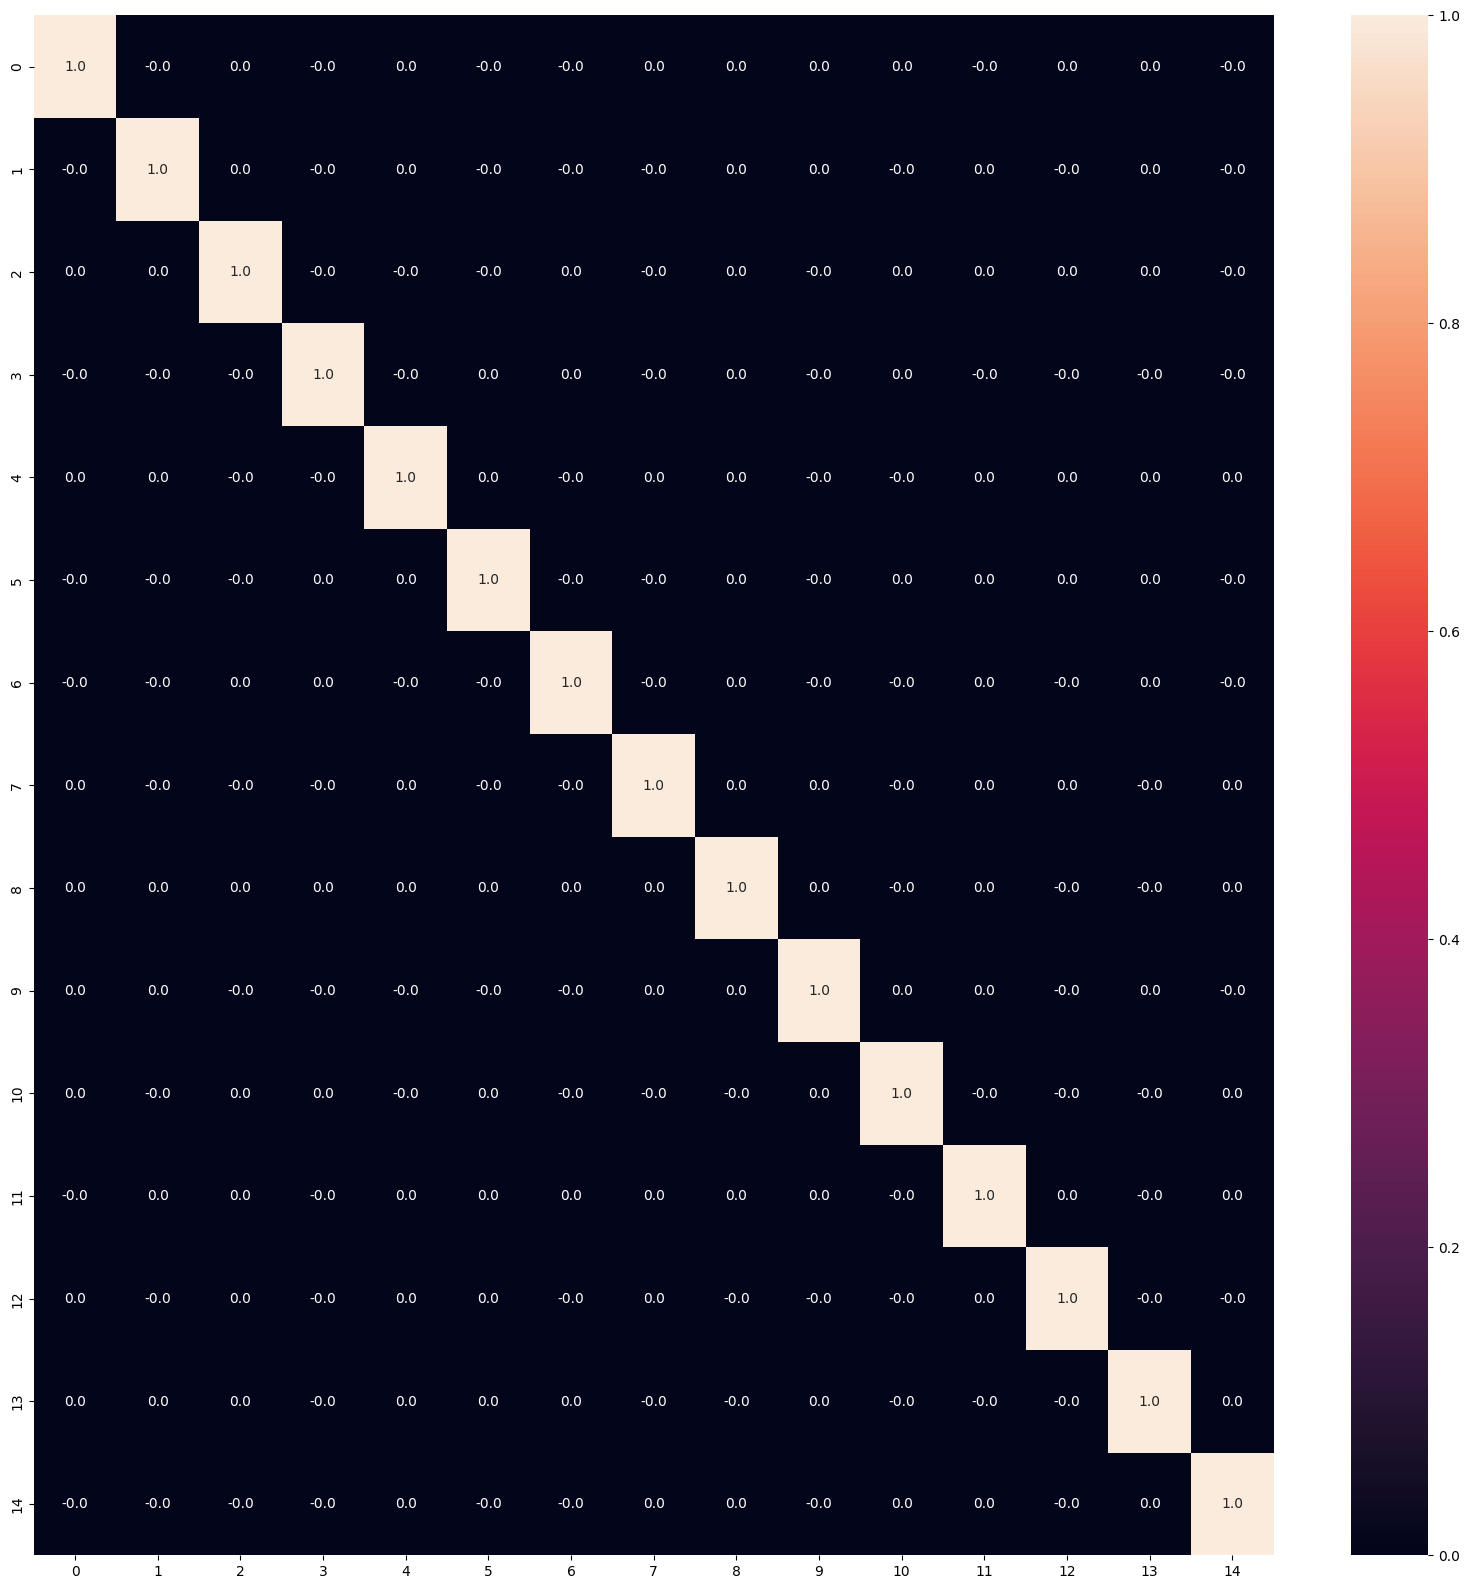

In [174]:
plt.figure(figsize=(20, 20))
sns.heatmap(principalData.corr(), annot=True, fmt=".1f")

In [8]:
evr = pca.explained_variance_ratio_
evr.sum()

0.7449860258667601

In [9]:
pca = PCA(.90)

principalComponents1 = pca.fit_transform(scaled_data)

In [10]:
pca.n_components_

26

In [11]:
from sklearn.decomposition import PCA

pca = PCA(n_components = 26)

principalComponents = pca.fit_transform(scaled_data)

principalData = pd.DataFrame(data = principalComponents)

evr = pca.explained_variance_ratio_
evr.sum()

0.9000101361948113

## Кластеризация

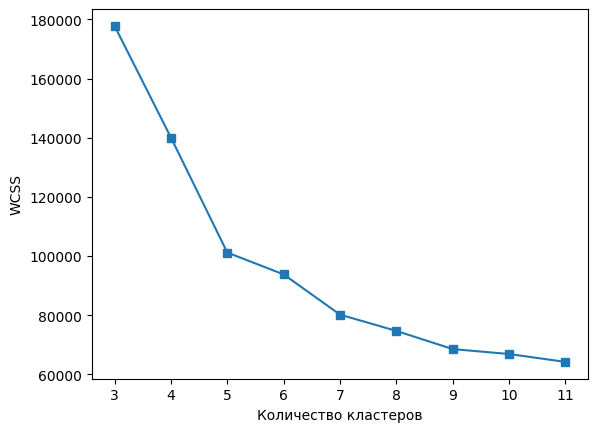

In [12]:
import numpy as np
import matplotlib.pyplot as plt
from sklearn.cluster import KMeans
inertia = []
for k in range(3, 12):
    kmeans = KMeans(n_clusters=k, random_state=42).fit(data)
    inertia.append(np.sqrt(kmeans.inertia_))

plt.plot(range(3, 12), inertia, marker='s')
plt.xlabel('Количество кластеров')
plt.ylabel('WCSS')
plt.show()

Elbow point (локть) - 5

In [19]:
best_model = KMeans( n_clusters=5,init ='k-means++').fit(data)

In [20]:
principalData['activityID'] = best_model.predict(data)
principalData['Index'] = [i for i in range(principalData['activityID'].size)]

In [21]:
def category_normal(data):
    un = data['activityID'].unique()
    res_dict = {i:1 for i in un}
    j = 1
    for i in res_dict.keys():
        res_dict[i] = j
        j+=1
    return res_dict

In [22]:
res_dict = category_normal(principalData)

principalData['activityID'] = principalData['activityID'].apply(lambda x : res_dict[x])

In [23]:
principalData

,0,1,2,3,4,5,6,7,8,9,...,18,19,20,21,22,23,24,25,activityID,Index
0,5.946109,0.364297,-0.173208,-0.853926,0.262714,-0.539950,-0.779423,-0.157257,1.759542,0.456760,...,-0.300113,-0.141065,0.256595,-0.007180,-0.147703,0.016261,-0.195875,0.376745,1,0
1,-1.155907,-4.236407,-1.788424,0.157810,-0.853420,0.577810,2.763084,-0.817617,-0.686467,-0.502126,...,-0.954952,-0.199384,-0.947623,0.093149,-0.012245,0.336984,1.197546,-0.445227,2,1
2,0.261861,2.906660,-2.048030,0.846311,0.823733,1.499587,-0.805782,0.938396,0.435055,0.466870,...,0.435965,0.798064,-1.272696,-0.587366,1.082140,-0.496757,0.169594,0.510532,3,2
3,-3.827059,1.148078,-0.049818,1.709193,-1.350799,0.667901,0.057444,-2.057719,0.042570,2.910965,...,-1.496938,0.337389,-1.401565,0.957392,0.333437,-0.034115,-3.231652,-0.195348,4,3
4,0.736508,-0.136346,1.206942,-2.239696,-0.065524,-0.565373,1.007924,0.323588,0.912312,-0.260916,...,0.212387,0.146496,-0.368895,-0.475831,0.202428,-0.247971,0.105716,0.122852,1,4
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
534596,-3.066955,-1.106519,0.571786,-1.058709,4.206519,-1.064162,1.436877,1.718608,1.263416,-0.915577,...,0.726754,-0.902540,-0.764369,1.284443,0.028084,0.161308,0.671063,0.737197,2,534596
534597,-1.398291,3.182467,1.595631,1.955506,0.235209,3.199405,0.323267,-0.719256,2.970315,0.330544,...,0.431415,0.903773,-1.393171,0.030594,0.039251,0.378108,-0.938277,-0.331368,5,534597
534598,-0.941498,1.889796,-0.969211,2.067463,0.584273,-0.714909,-0.619927,0.683698,1.094694,1.102249,...,1.492795,-0.134002,0.895552,0.216056,-0.876026,-0.222462,0.501215,-1.643911,5,534598
534599,-5.169027,1.456140,5.813303,-0.799240,2.908094,-1.204834,-0.541905,-1.905557,0.262637,-4.630289,...,3.393774,1.681807,-2.495109,-0.272384,4.139051,3.222179,1.880012,1.427205,2,534599


In [24]:
principalData.to_csv('p123redi123456ct.csv',index = False,columns = ['Index','activityID'])

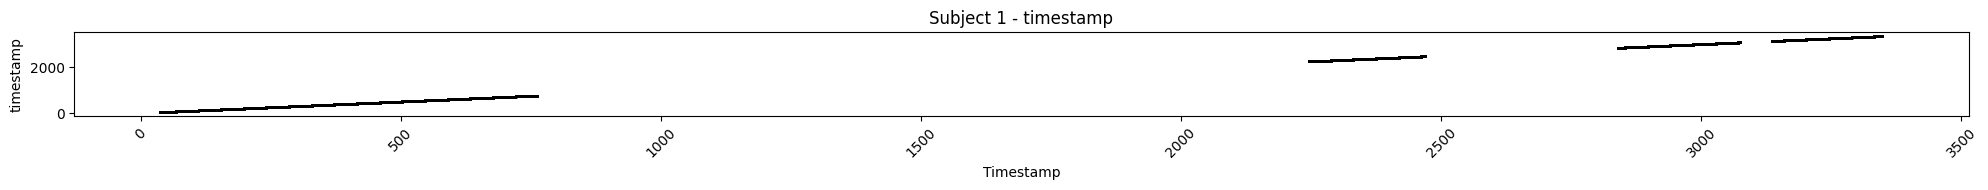

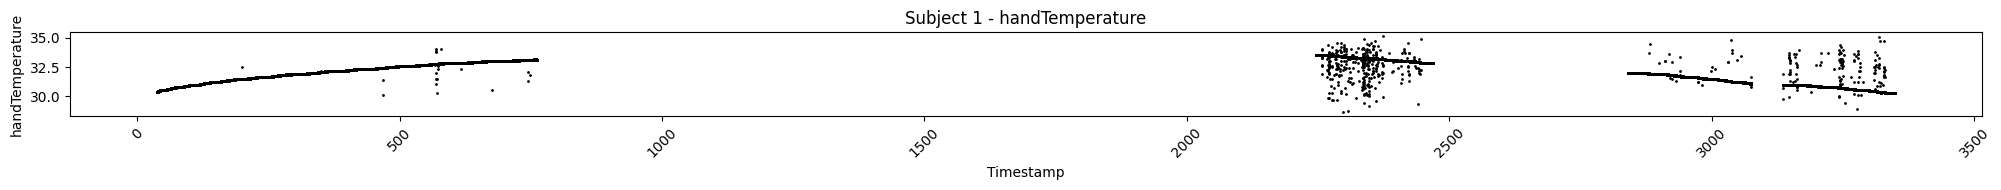

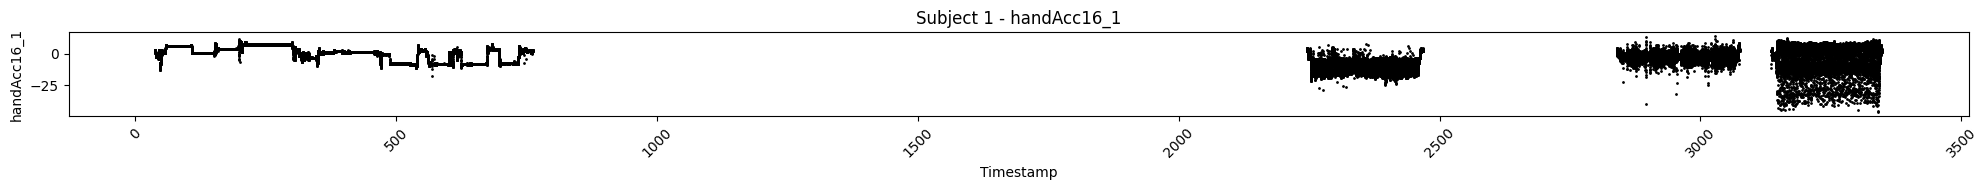

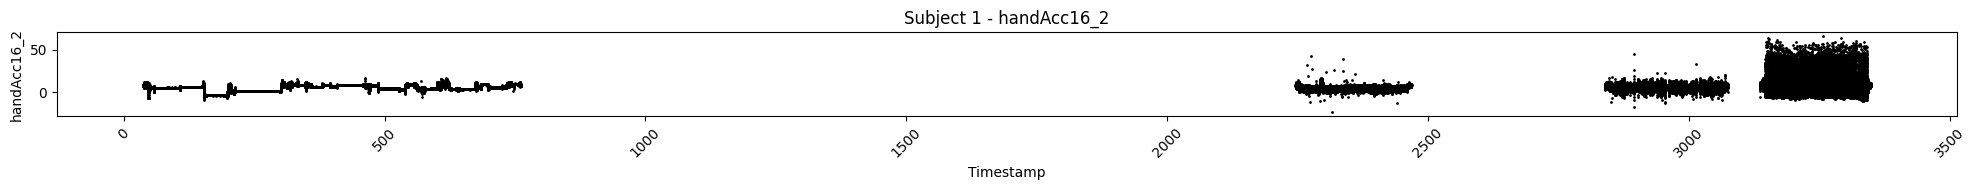

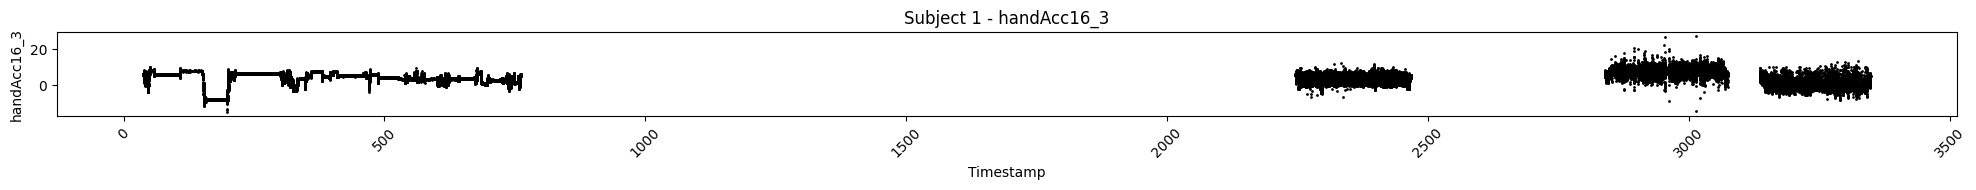

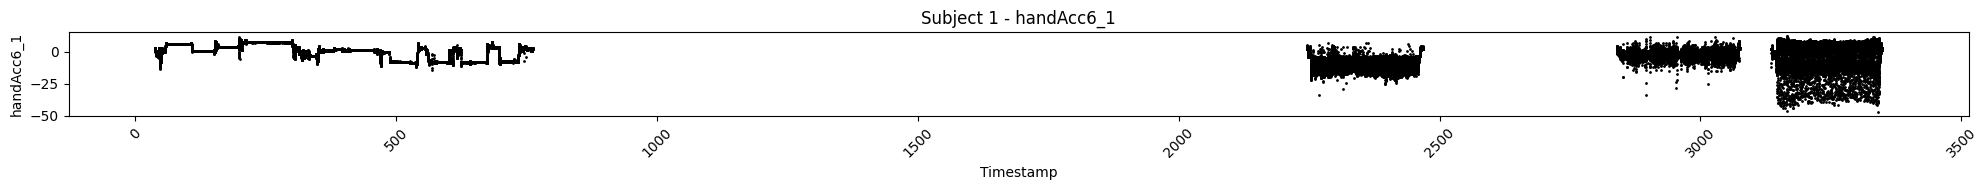

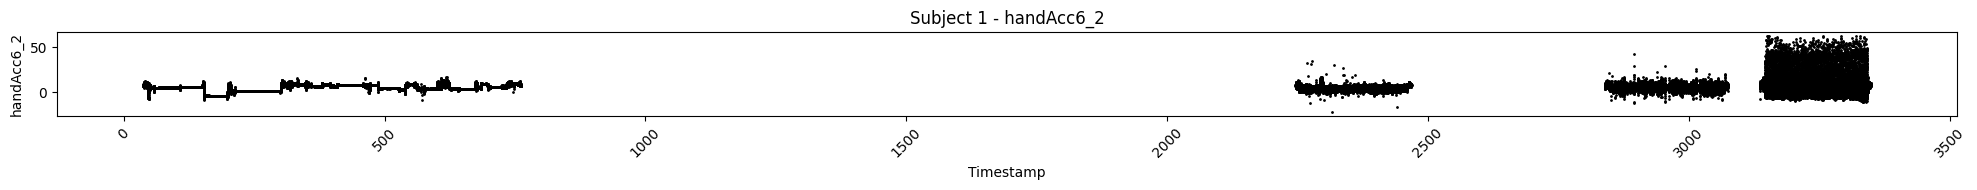

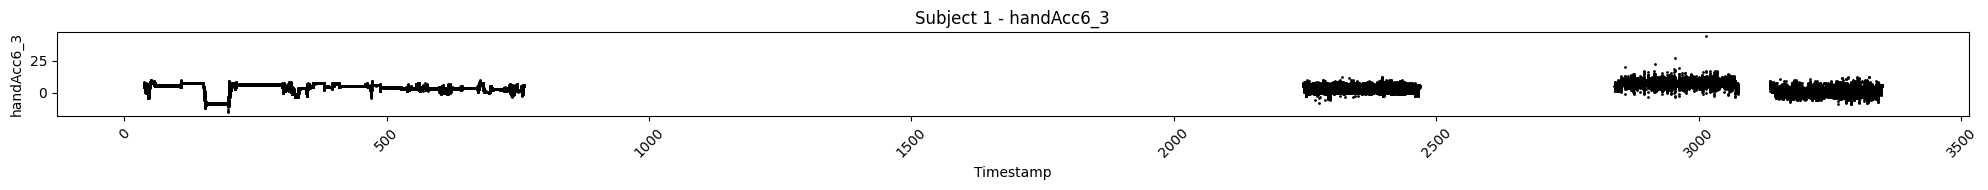

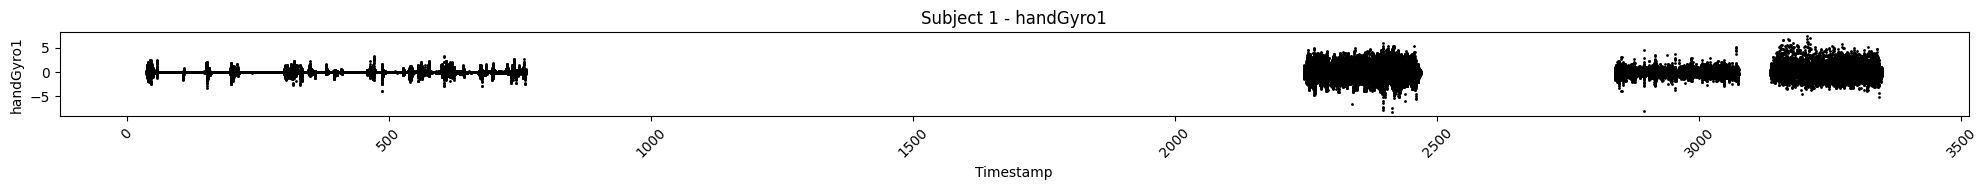

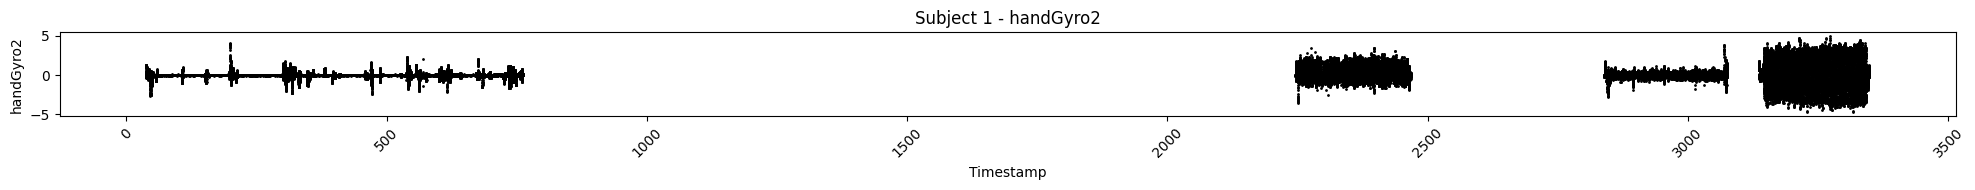

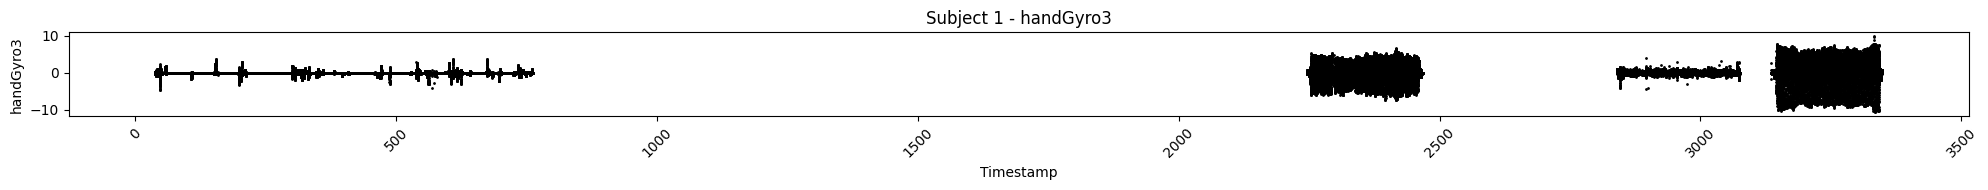

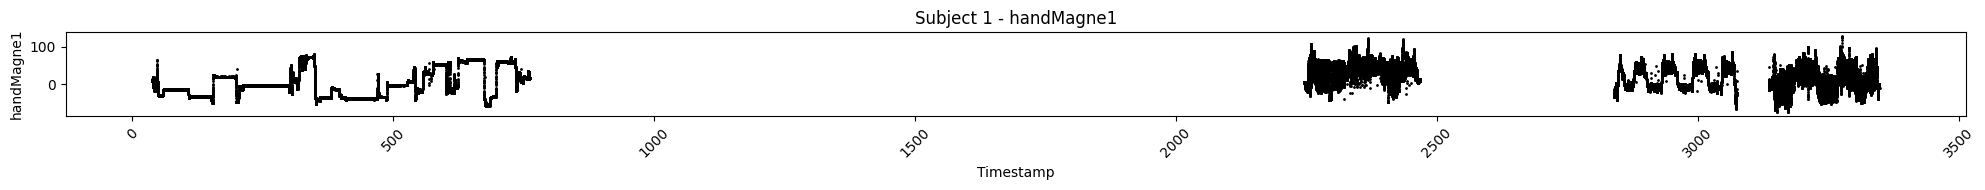

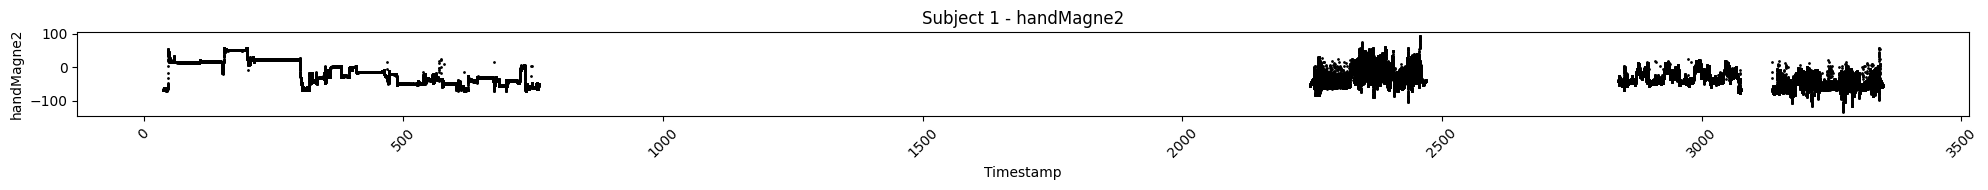

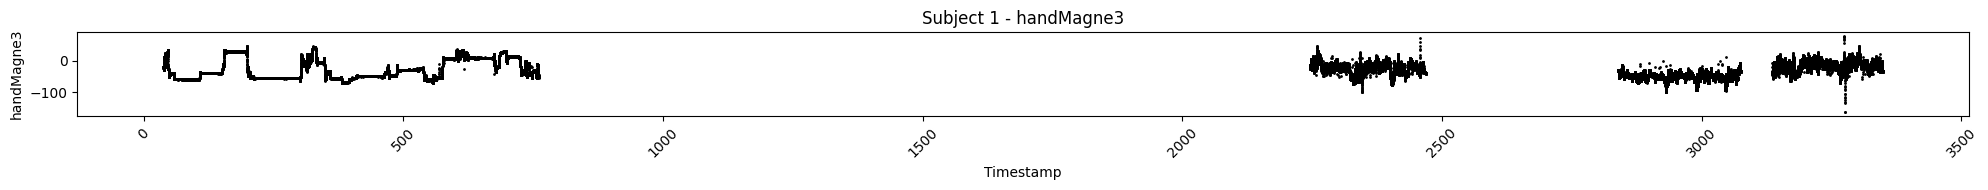

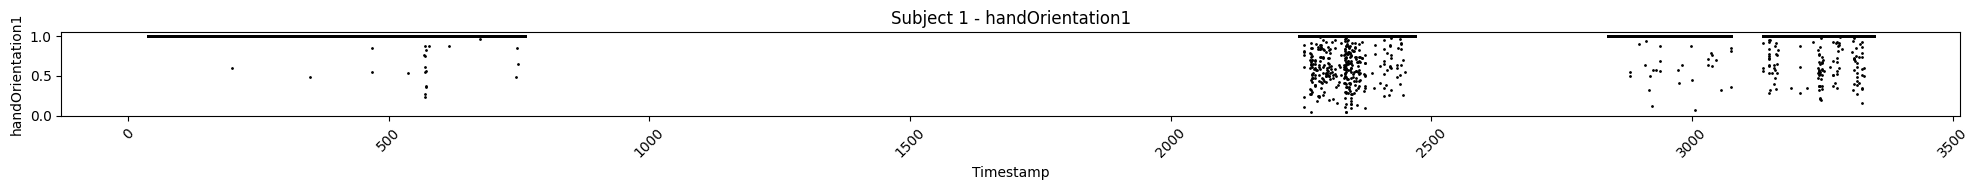

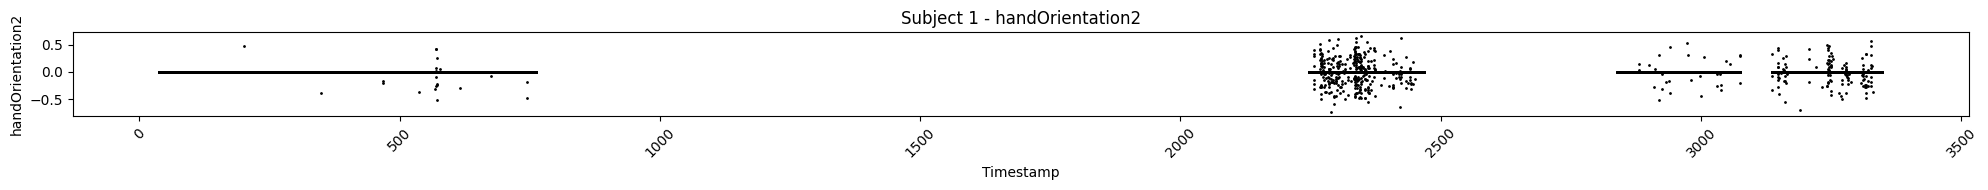

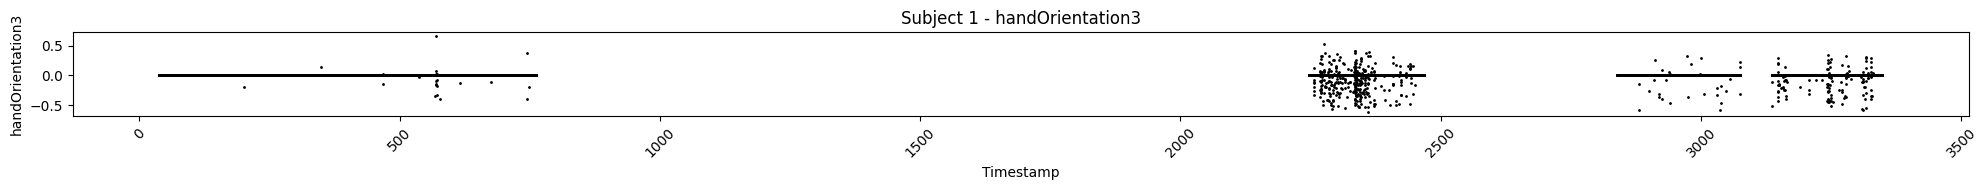

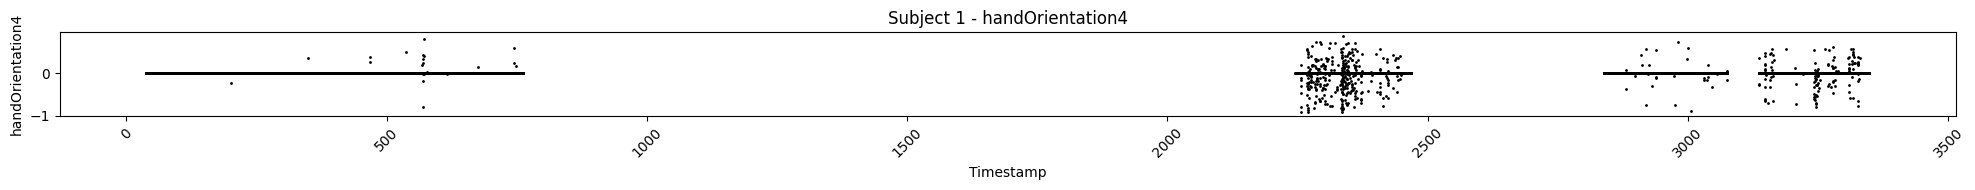

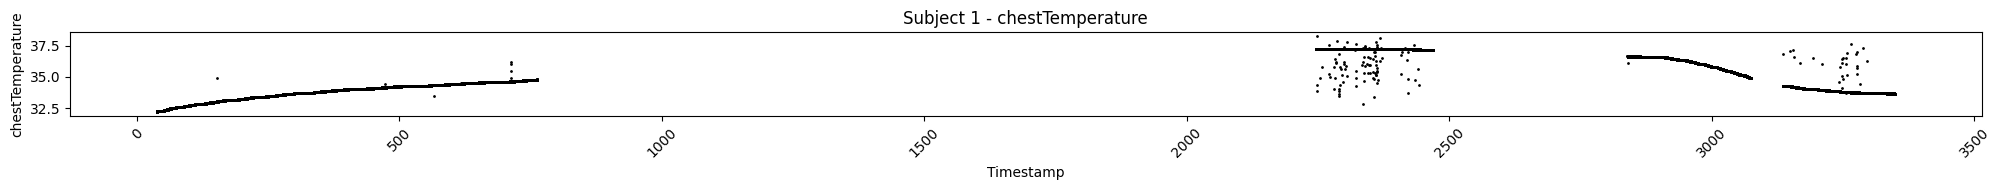

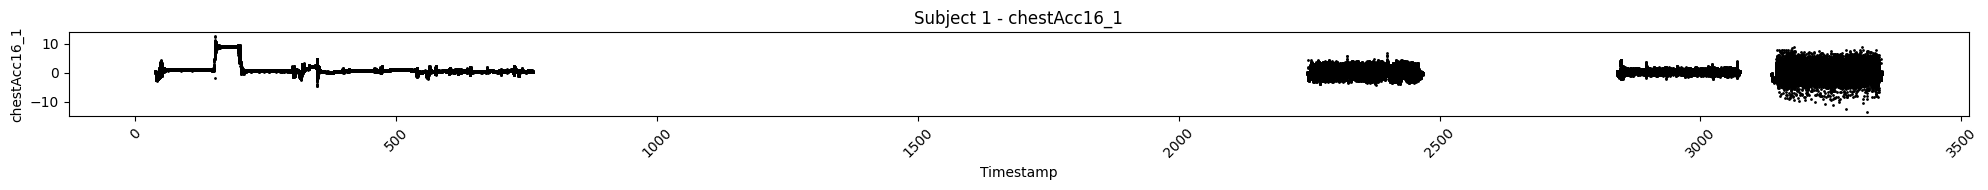

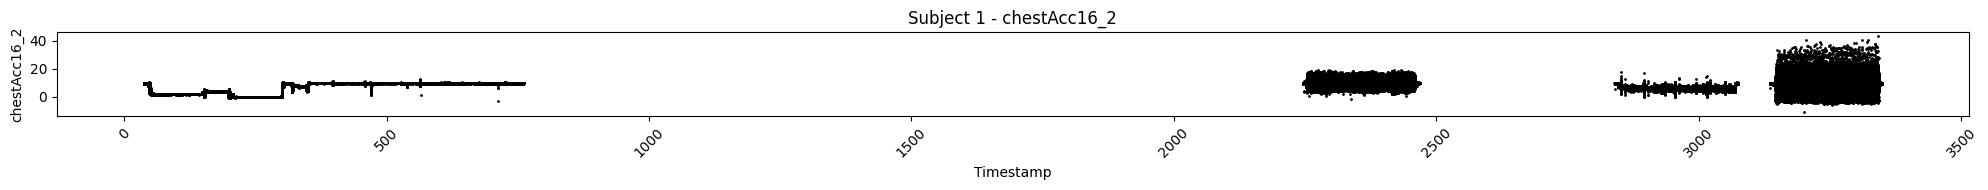

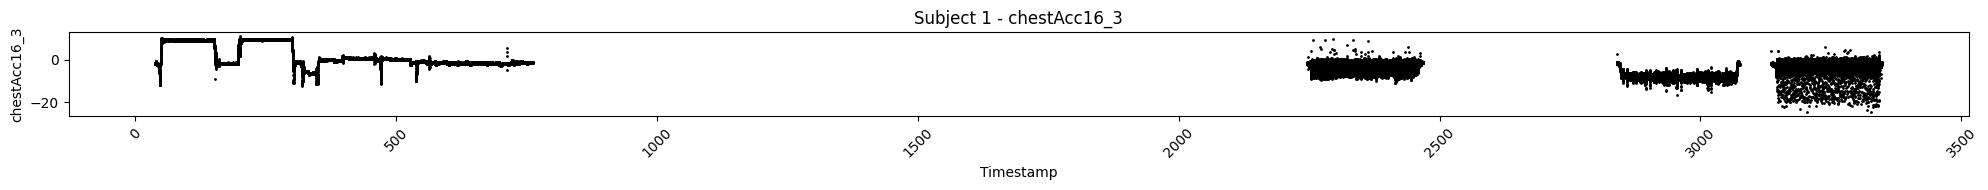

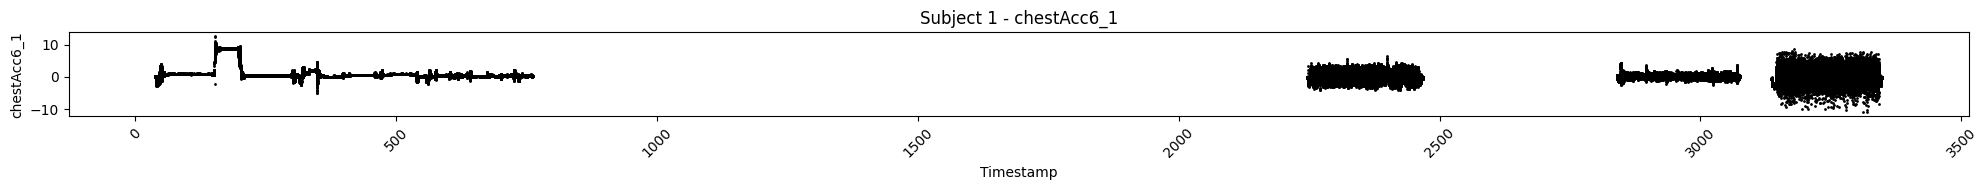

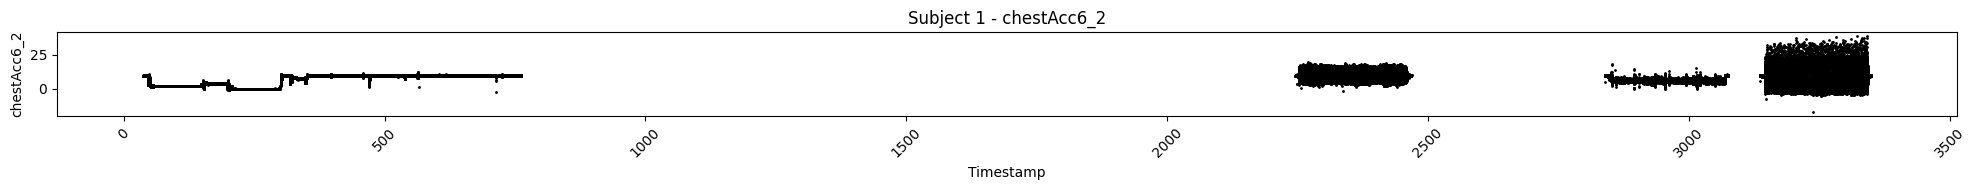

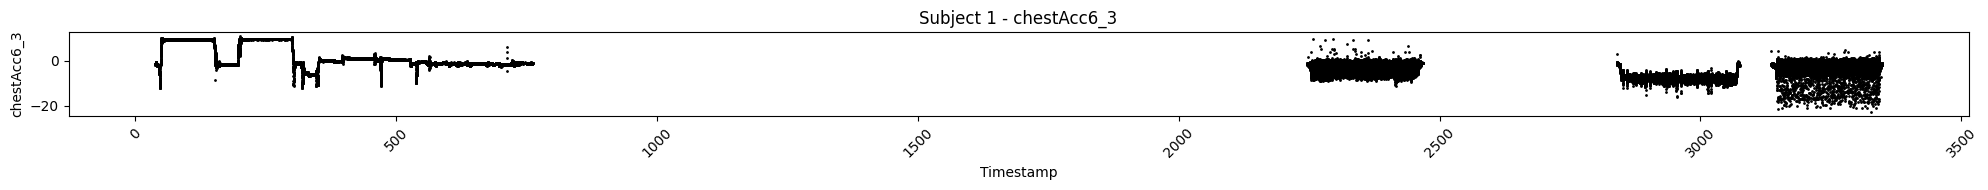

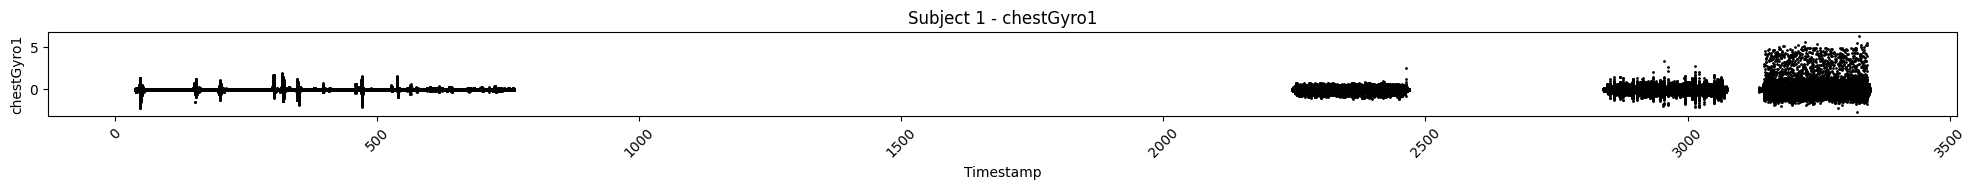

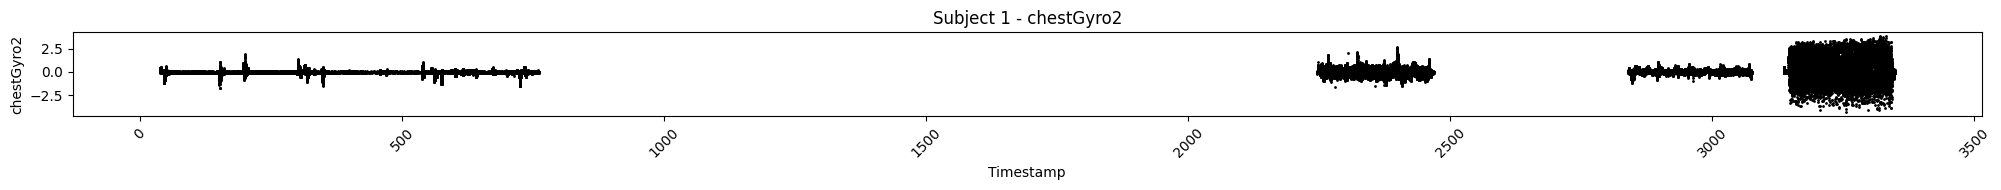

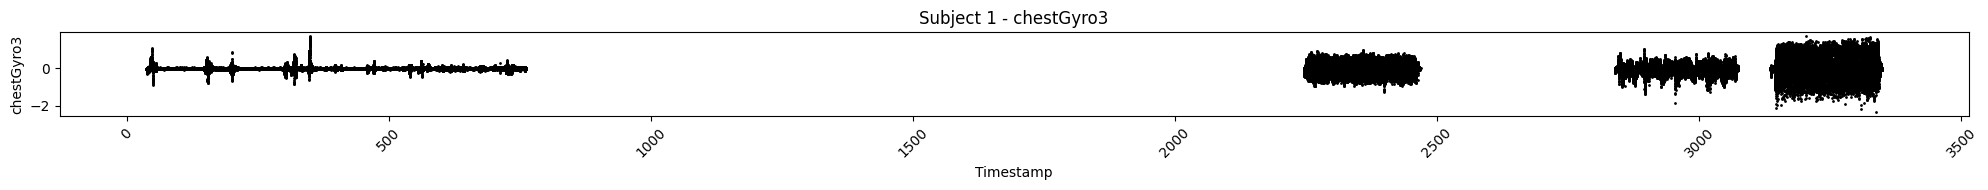

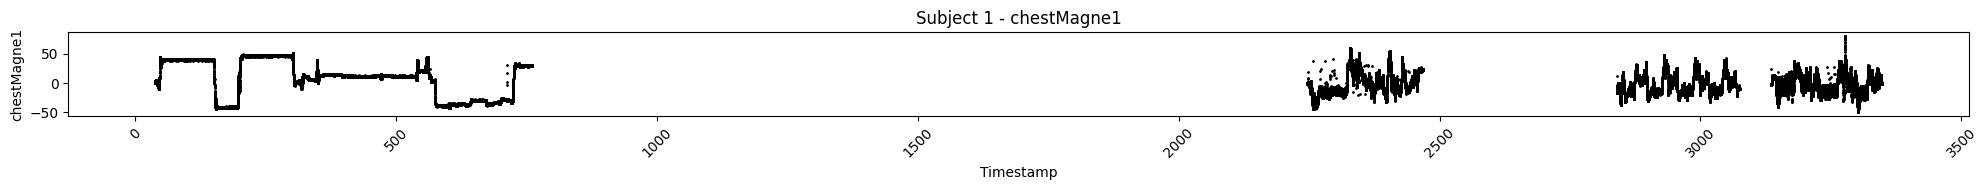

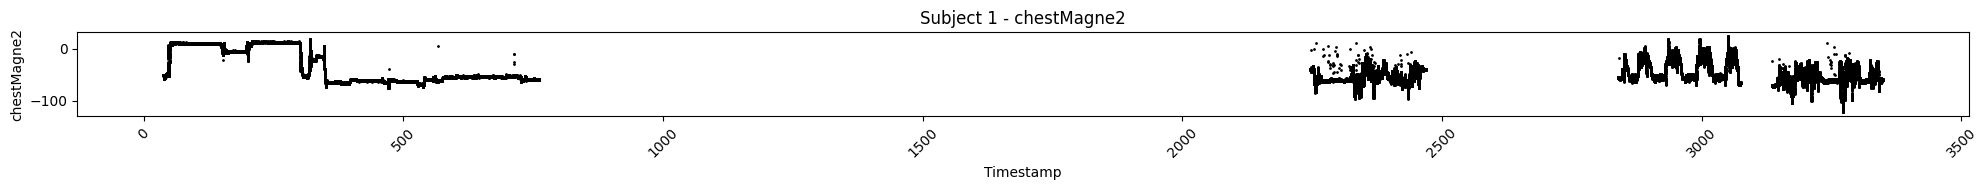

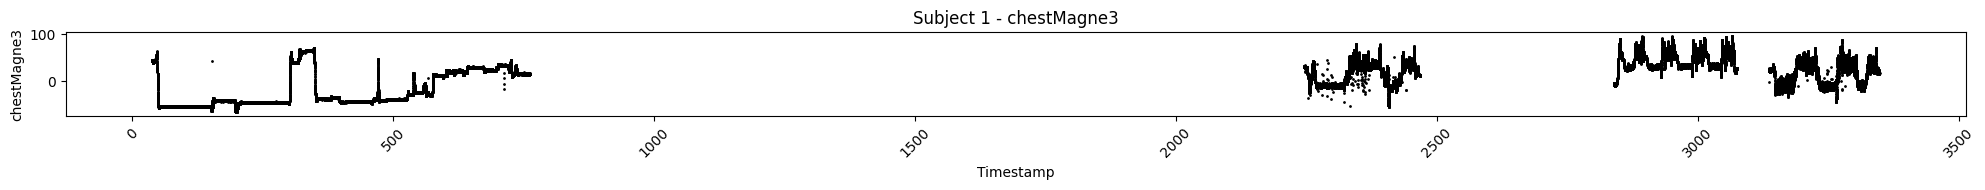

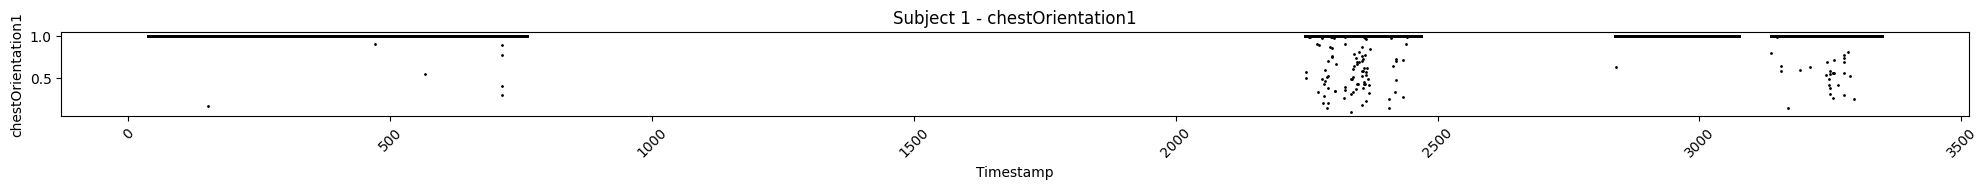

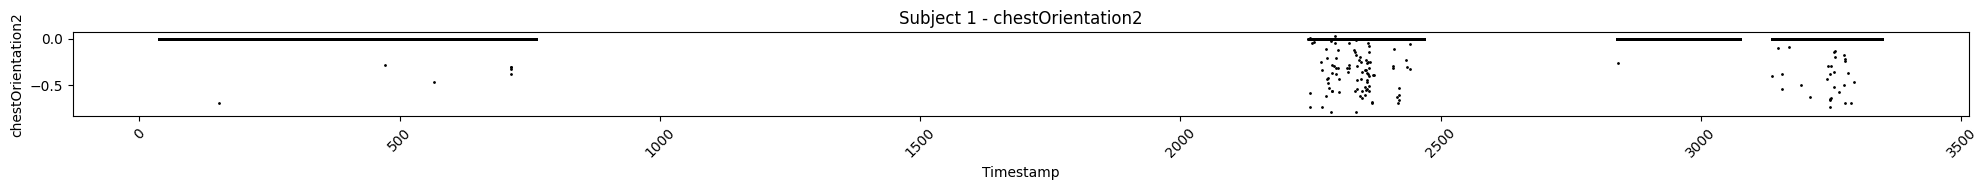

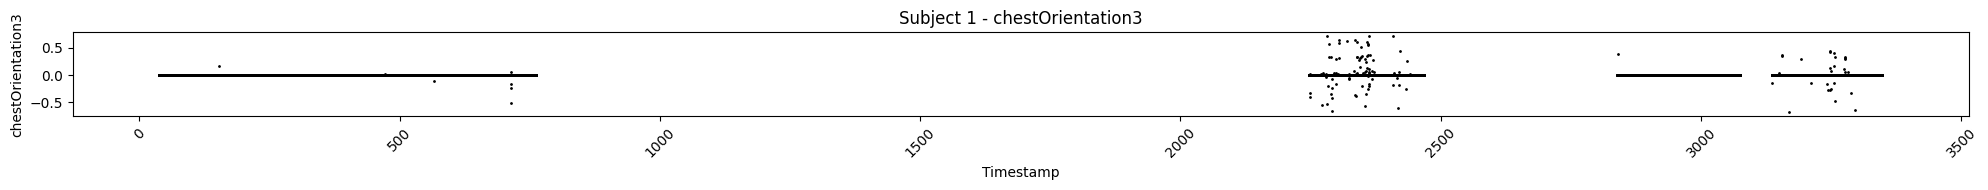

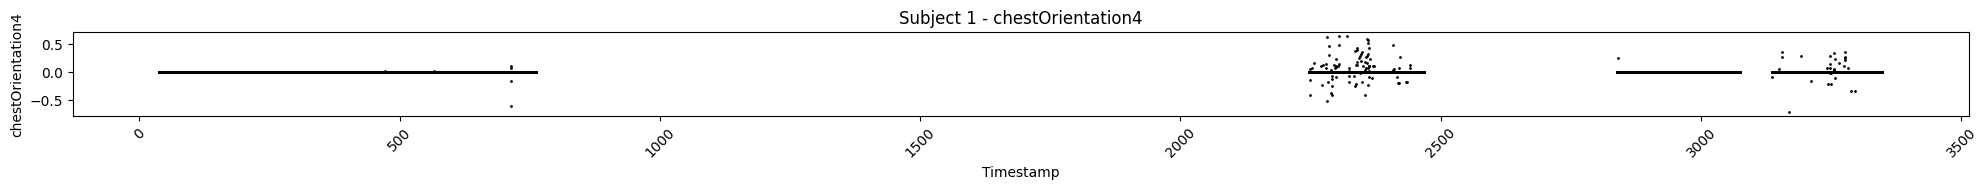

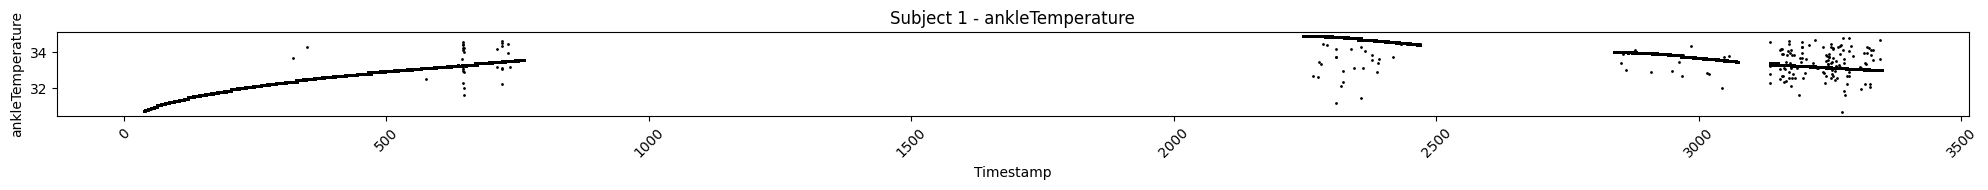

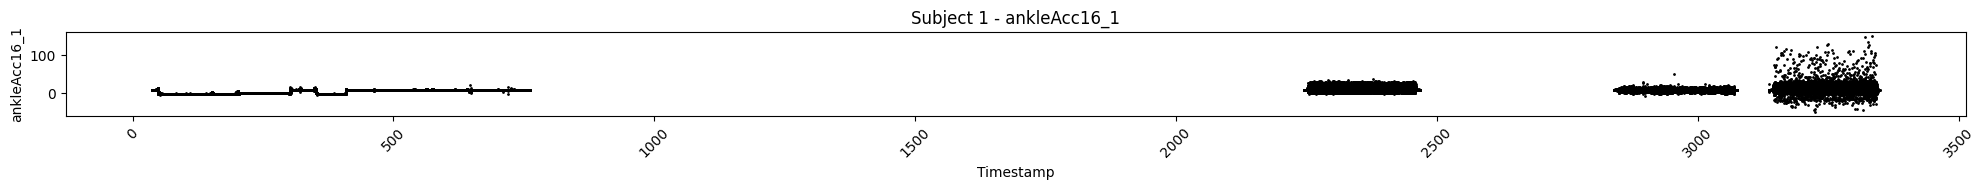

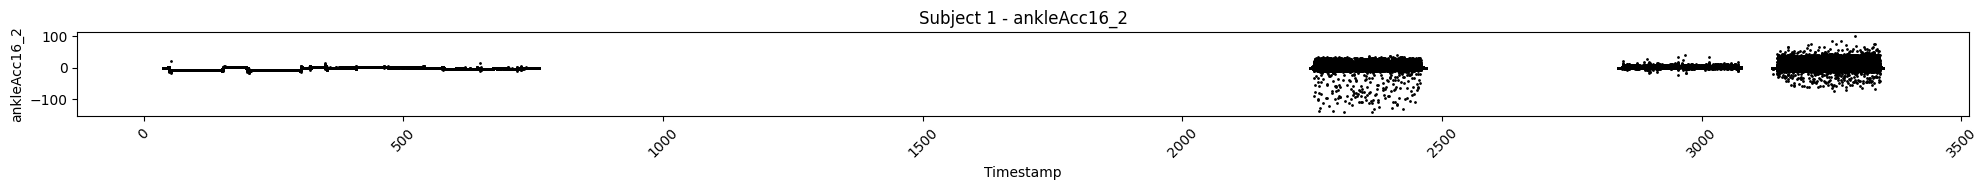

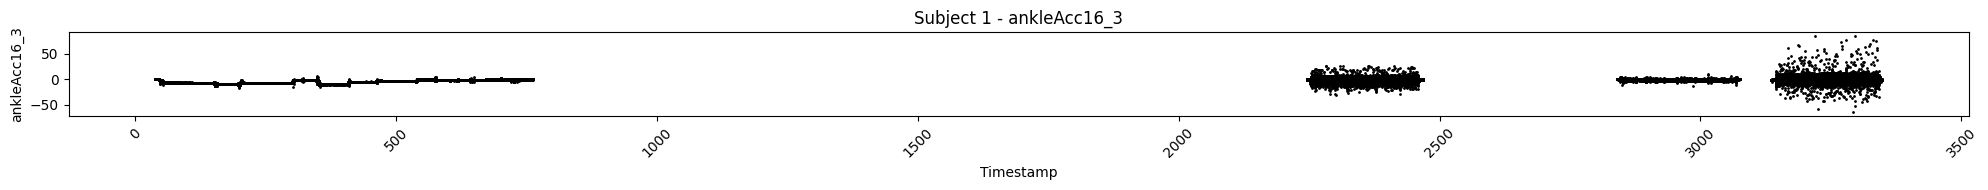

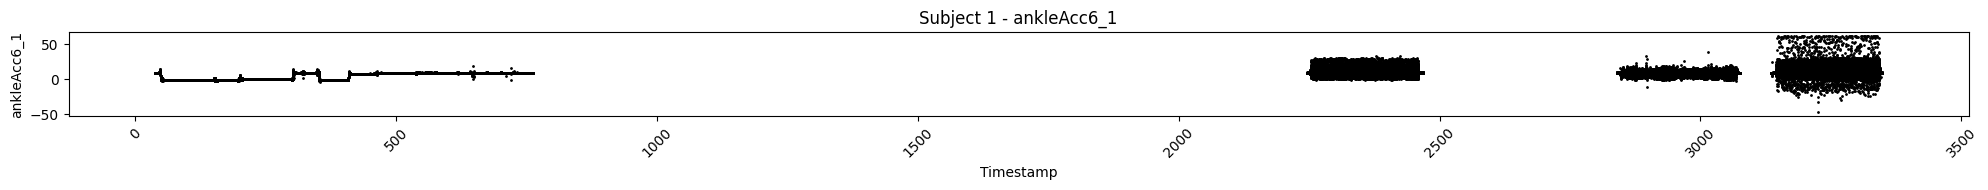

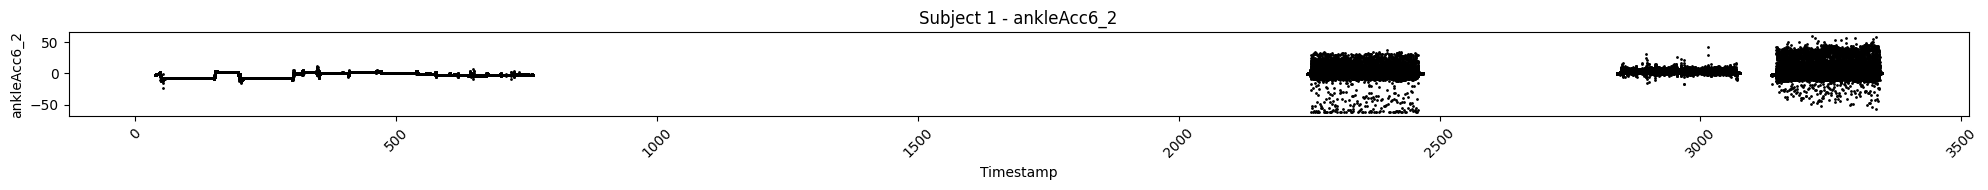

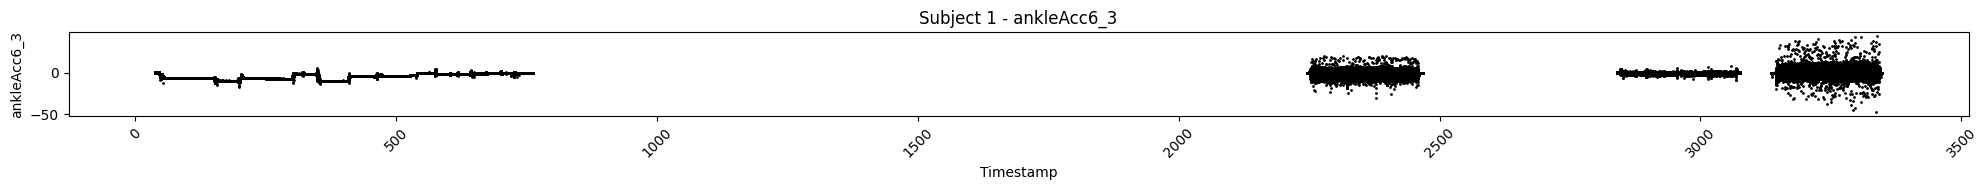

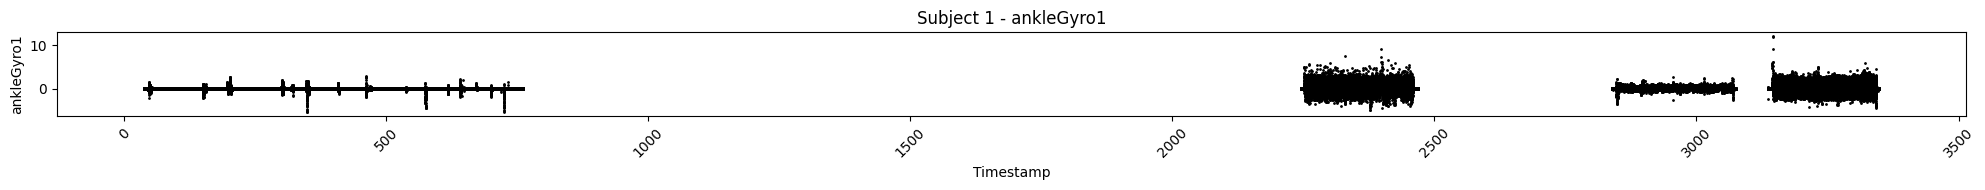

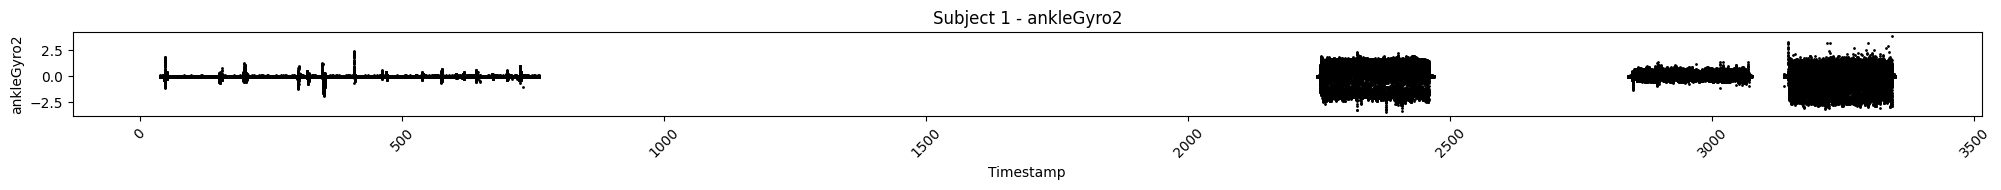

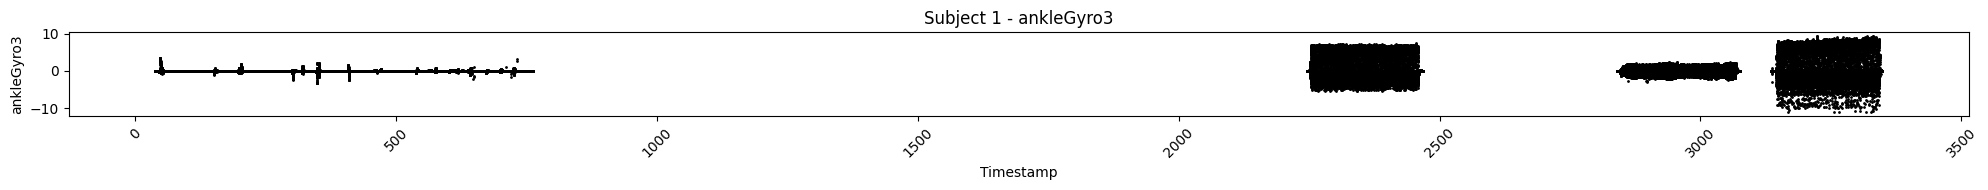

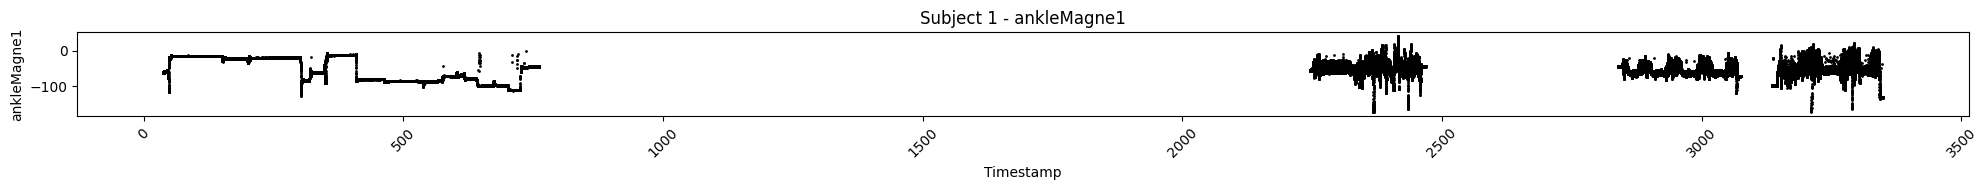

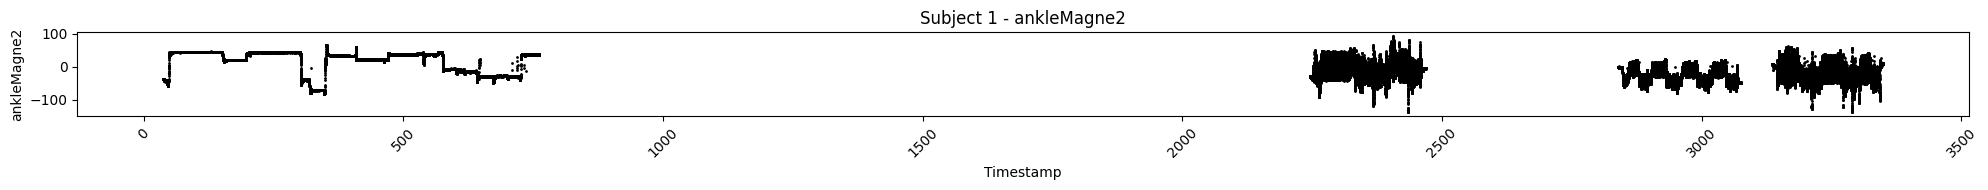

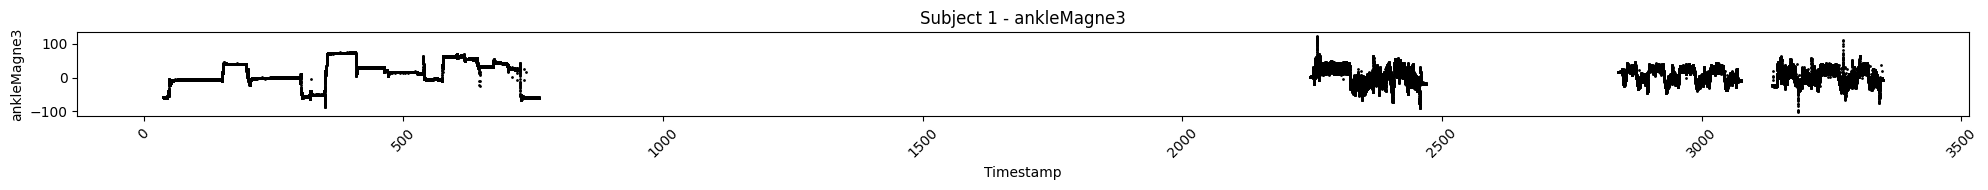

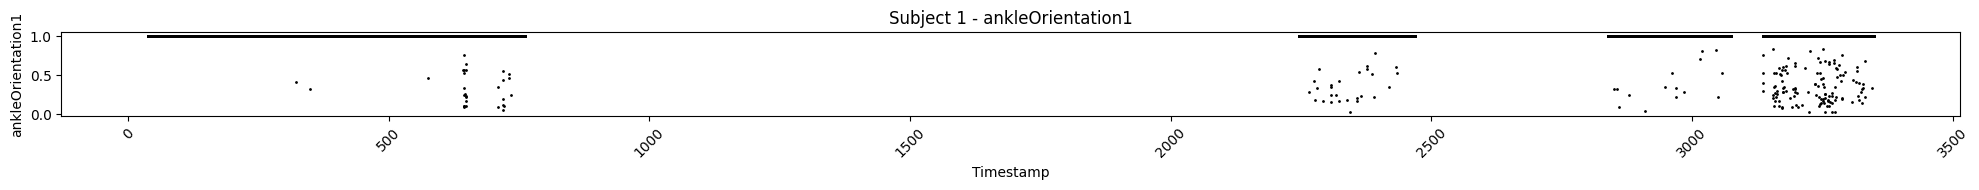

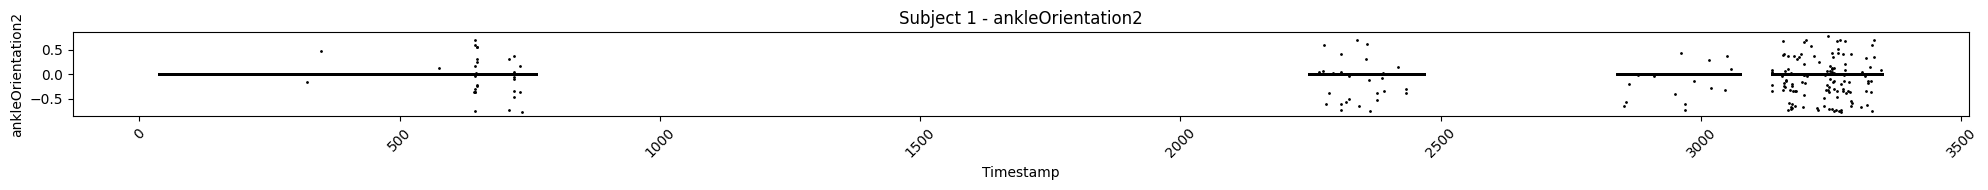

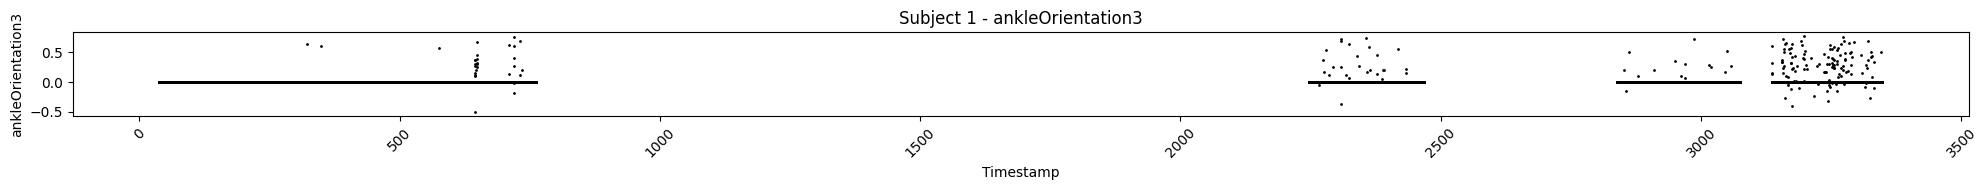

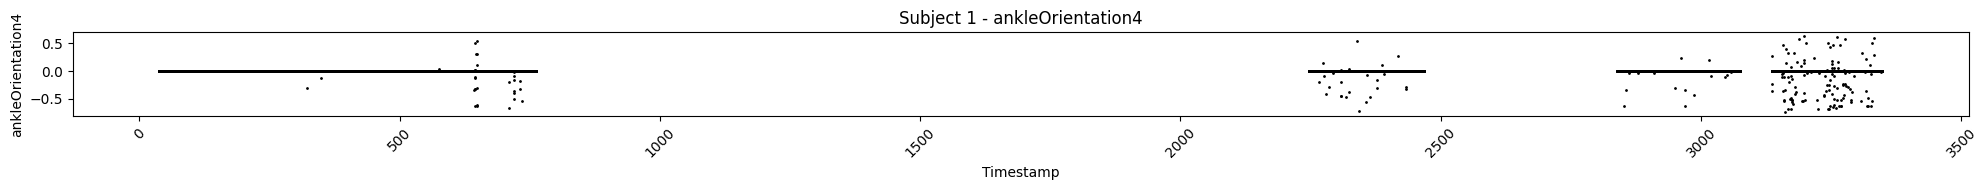

In [28]:
subject_id = 1
d = data.loc[data['subject_id'] == subject_id].sort_values(by='timestamp')
d.index = d['timestamp']
d.drop(columns='subject_id', inplace=True)

# Получаем список всех столбцов, кроме timestamp
columns_to_plot = d.columns

# Создаем графики для всех столбцов
for column in columns_to_plot:
    plt.figure(figsize=(20, 2))
    plt.scatter(d.index, d[column], c="black", s=1)
    plt.title(f"Subject {subject_id} - {column}")
    plt.xlabel('Timestamp')
    plt.ylabel(column)
    plt.xticks(rotation=45)  # Поворачиваем метки по оси X для удобства чтения
    plt.tight_layout()  # Упрощает компоновку графика
    plt.show()